In [1]:
import pyvista as pv
import geopandas as gpd
import pandas as pd
import numpy as np
import glob
import os
import sys

from scipy.spatial import cKDTree
from shapely.geometry import Point, LineString, Polygon, box

# For fontwriter
import fontTools
from fontTools.ttLib import TTFont
import uharfbuzz as hb
from pathlib import Path

from svgpathtools import svg2paths2

import shutil

# import itertools
# from operator import itemgetter

# from skimage.draw import line_nd
# import scipy
# import pymeshfix as mf
# import datetime

In [ ]:
# ===== OLD VERSION (Louisiana DNR 1138) =====
# ## Independent run location
# path = os.getcwd().replace('\\','/')
# basepath = path.split('/python/SiteWideModel')[0]
# 
# ## CRS
# crs = 'EPSG:26782'
# ===== END OLD VERSION =====

## Independent run location
path = os.getcwd().replace('\\','/')
basepath = r"Z:\Targa Resources 1052\1052-XX Targa - MBV Model\3_Analysis_CavernModel\python\Dome Wide Model".replace('\\','/')

## CRS
crs = 'EPSG:32040'


In [ ]:
# ===== OLD VERSION (Louisiana DNR 1138) =====
# ## Use Ceyhan's sheet
# path = basepath + "/python_inputs/DATABASE_05222026.xlsx"
# path = r"Z:\Louisiana DNR 1138\3.0 Analysis\python\Point_Cloud_search_mwb202607.xlsx" #< matt's edited one with point clouds
# path = r"C:\scipts\1138-01\python_inputs\Point_Cloud_search_mb.xlsx"
# df = pd.read_excel(path)
# df.head()
# ===== END OLD VERSION =====

path = r"Z:\Targa Resources 1052\1052-XX Targa - MBV Model\3_Analysis_CavernModel\Sonar_with_dev_database.xlsx"
df = pd.read_excel(path, sheet_name='WA Wells')
df.head()


In [ ]:
# ===== OLD VERSION (Louisiana DNR 1138 - was disabled with if False:) =====
# ## Use file structure
# if False:
#     ## Sonar STLs0
#     spath = f'{basepath}/python_inputs/stl/simplified/*.stl'
#     files = [x.replace('\\','/') for x in glob.glob(spath)]
#     df = pd.DataFrame({'path':files})
#     df['fname'] = df.path.apply(lambda x: x.split('/')[-1])
#     df['name'] = df.fname.apply(lambda x: x.split('_')[0])
#     
#     df['dt'] = df.fname.str.extract(r'(\d{4}0[1-9]|1[0-2])')
#     df['year'] = df.fname.str.extract(r'(19\d{2}|20\d{2})').astype(float)
#     
#     import re
#     
#     for index, row in df[df.dt.isnull()].iterrows():
#         n = row['fname']
#         if '19931231' in n:
#             df.at[index, 'dt'] = '19931231'
#             continue
#         if '_1993_' in n:
#             df.at[index, 'dt'] = '19931231'
#             continue
#             
#         pattern = r'20[\d]{4}'
#         m = re.search(pattern, n)
#         if m:
#             year = int(m.group()[2:])
#             print(year)
#             dt = f'{year}1231'
#             df.at[index, 'year'] = year
#             df.at[index, 'dt'] = dt
#     
#     
#     df['dt'] = df['dt'].where(df.dt.apply(lambda x: len(str(x)) != 6), other= df['dt'] + '01')
#     # Latest IP
#     for name, group in df.groupby('name'):
#         group = group.sort_values('year', ascending=False)
#         #i = group
#         if group.shape[0] > 1:
#             break # not finished
#                
# df.head()
# ===== END OLD VERSION =====

import re

stl_dir = r"Z:\Targa Resources 1052\1052-XX Targa - MBV Model\3_Analysis_CavernModel\STL"
stl_paths = [x.replace('\\','/') for x in glob.glob(f'{stl_dir}/*.stl')]

stl_df = pd.DataFrame({'path': stl_paths})
stl_df['fname'] = stl_df.path.apply(lambda x: x.split('/')[-1])

# filenames look like WA33_20140826_scaled.stl or WA20A_20240218_scaled.stl
stl_df['Map_Identifier'] = stl_df.fname.apply(lambda x: x.split('_')[0])
stl_df['dt'] = stl_df.fname.str.extract(r'(\d{8})')
stl_df['dt'] = pd.to_datetime(stl_df['dt'], format='%Y%m%d', errors='coerce')

# Keep only the most recent STL per Map_Identifier
stl_latest = stl_df.sort_values('dt', ascending=False).drop_duplicates('Map_Identifier', keep='first')

df = df.merge(stl_latest[['Map_Identifier','path','dt']], on='Map_Identifier', how='left')
df.head()


In [ ]:
# ===== OLD VERSION (Louisiana DNR 1138) =====
# ## Dev Surveys
# spath = f'{basepath}/python_inputs/DevSurvey/DevSurvey_geopackages_May2026/Lines/*.gpkg'
# paths = [x.replace('\\','/') for x in glob.glob(spath)]
# 
# lines = gpd.read_file(paths[0])
# if lines.crs != crs:
#     lines.to_crs(crs, inplace=True)
# lines['name'] = paths[0].split('/')[-1].split('_')[0]
# 
# for path in paths[1:]:
#     t = gpd.read_file(path)
#     if t.crs != crs:
#         t.to_crs(crs, inplace=True)
#     t['name'] = path.split('/')[-1].split('_')[0]
#     lines = pd.concat([lines, t], ignore_index=True)
#     print('.', end='')
# lines = gpd.GeoDataFrame(lines, geometry='geometry', crs=crs)
# lines.plot()
# ===== END OLD VERSION =====

dev_dir = r"Z:\Targa Resources 1052\1052-XX Targa - MBV Model\Targa Well Log Deviation Survey Processing\Dev Survey Processed gpkgs\Lines"
dev_paths = [x.replace('\\','/') for x in glob.glob(f'{dev_dir}/*.gpkg')]

dev_index = pd.DataFrame({'path': dev_paths})
dev_index['fname'] = dev_index.path.apply(lambda x: x.split('/')[-1])
dev_index['CJ_Numbering'] = dev_index.fname.str.extract(r'^(\d+)\.').astype(float)
dev_index['dt'] = dev_index.fname.str.extract(r'_(\d{8})_line')
dev_index['dt'] = pd.to_datetime(dev_index['dt'], format='%Y%m%d', errors='coerce')

# Bring in Map_Identifier from the Excel database via CJ Numbering
dev_index = dev_index.merge(
    df[['CJ Numbering','Map_Identifier']].rename(columns={'CJ Numbering':'CJ_Numbering'}),
    on='CJ_Numbering', how='left'
)

# Keep only the most recent survey per well
dev_latest = dev_index.sort_values('dt', ascending=False).drop_duplicates('Map_Identifier', keep='first')
dev_latest = dev_latest.dropna(subset=['Map_Identifier'])

print(f'{len(dev_index)} total survey files -> {len(dev_latest)} wells after keeping latest only')

lines = gpd.read_file(dev_latest.iloc[0]['path'])
if lines.crs != crs:
    lines.to_crs(crs, inplace=True)
lines['Map_Identifier'] = dev_latest.iloc[0]['Map_Identifier']

for i in range(1, len(dev_latest)):
    row = dev_latest.iloc[i]
    t = gpd.read_file(row['path'])
    if t.crs != crs:
        t.to_crs(crs, inplace=True)
    t['Map_Identifier'] = row['Map_Identifier']
    lines = pd.concat([lines, t], ignore_index=True)
    print('.', end='')

lines = gpd.GeoDataFrame(lines, geometry='geometry', crs=crs)
lines.plot()


In [ ]:
# ===== OLD VERSION (Louisiana DNR 1138 - read from shapefile) =====
# path = f'{basepath}/python_inputs/shp/Wells_20260127.shp'
# wells = gpd.read_file(path)
# wells.to_crs(crs, inplace=True)
# wells.plot()
# ===== END OLD VERSION =====

wellspath = r"Z:\Targa Resources 1052\1052-XX Targa - MBV Model\3_Analysis_CavernModel\wells_20260512.gpkg"  # TODO: confirm real network path
wells = gpd.read_file(wellspath)
if wells.crs != crs:
    wells.to_crs(crs, inplace=True)
wells.plot()


In [7]:
## DEM merge - building surface data
if False:
    paths = [r"C:\scipts\1138-01\DEM\USGS_1M_15_x45y335_LA_Sabine_River_Lidar_2018_D18.tif",
    r"C:\scipts\1138-01\DEM\USGS_1M_15_x46y335_LA_Sabine_River_Lidar_2018_D18.tif"]
    
    import rasterio
    from rasterio.merge import merge
    # import glob
    
    # 1. Open all .tif files in the current directory
    # files = glob.glob("*.tif")
    src_files = [rasterio.open(f) for f in paths]
    
    # 2. Merge files and generate new transform
    mosaic, out_trans = merge(src_files)
    
    # 3. Update metadata from the first file for output
    out_meta = src_files[0].meta.copy()
    out_meta.update({
        "driver": "GTiff",
        "height": mosaic.shape[1],
        "width": mosaic.shape[2],
        "transform": out_trans,
        "compress": "lzw"
    })
    
    # 4. Write output and close datasets
    with rasterio.open("DEM_merged_1m.tif", "w", **out_meta) as dest:
        dest.write(mosaic)
    
    for src in src_files:
        src.close()


In [ ]:
# ===== OLD VERSION (Louisiana DNR 1138) =====
# ## From pulling surfac informaton
# xmin, ymin, xmax, ymax = wells.total_bounds
# d = 500
# bbox = box(xmin-d, ymin-d, xmax+d, ymax+d)
# utmcrs = 'EPSG:26915'
# bboxgdf = gpd.GeoDataFrame({'geometry':[bbox]}, crs=crs).to_crs(utmcrs)
# 
# ===== END OLD VERSION =====

## From pulling surface information
xmin, ymin, xmax, ymax = wells.total_bounds
d = 500
bbox = box(xmin-d, ymin-d, xmax+d, ymax+d)
utmcrs = 'EPSG:26915'  # TODO: confirm this matches the CRS of your Targa DEM/aerial raster files
bboxgdf = gpd.GeoDataFrame({'geometry':[bbox]}, crs=crs).to_crs(utmcrs)


In [12]:
# contours_dict = a
# result = {}

# for color, contours in contours_dict.items():

#     polys = []

#     # allow multiple contours per color
#     if isinstance(contours, np.ndarray):
#         contours = [contours]

#     for pts in contours:

#         if len(pts) < 3:
#             continue

#         ring = LinearRing(pts)

#         # ensure closure
#         if not np.allclose(pts[0], pts[-1]):
#             pts = np.vstack([pts, pts[0]])

#         poly = Polygon(pts)

#         if poly.is_valid:
#             polys.append(poly.buffer(0))  # fixes minor self-intersections

#         break

#     # merge same-color shapes
#     result[color] = unary_union(polys)

# poly.buffer(0)

In [13]:
from svgpathtools import svg2paths2
import numpy as np

def path_to_subpaths(path):
    subpaths = []
    current = []

    for seg in path:
        current.append(seg)

        # end of subpath marker
        print(current)
        if seg.end == path[0].start or str(seg) == 'Z':
            if current:
                subpaths.append(current)
                current = []

    if current:
        subpaths.append(current)

    return subpaths

def sample_subpath(subpath, n=20):
    pts = []

    for seg in subpath:
        t = np.linspace(0, 1, n, endpoint=False)

        for tt in t:
            p = seg.point(tt)
            pts.append([p.real, p.imag])

    return np.array(pts)

def signed_area(poly):
    x = poly[:, 0]
    y = poly[:, 1]
    return 0.5 * np.sum(x[:-1]*y[1:] - x[1:]*y[:-1])



In [14]:
# subpaths = path_to_subpaths(path)

# for subpath in subpaths:
#     a = sample_subpath(subpath, n=20)
#     break
# a

In [15]:
import numpy as np
from svgpathtools import svg2paths2


def svg_to_contours(svg_file, samples_per_curve=20):
    """
    Read an SVG and return sampled contours grouped by color.

    Parameters
    ----------
    svg_file : str
        Path to SVG file.
    samples_per_curve : int, default=20
        Number of samples per curve segment.

    Returns
    -------
    dict[str, list[np.ndarray]]
        Dictionary mapping SVG colors to a list of contours.
        Each contour is an (N, 2) ndarray.
    """

    paths, attributes, svg_attributes = svg2paths2(svg_file)

    def extract_color(attr):
        """Return fill/stroke color from SVG attributes."""
        if not attr:
            return "#000000"

        for key in ("fill", "stroke"):
            value = attr.get(key)
            if value and value.lower() != "none":
                return value

        style = attr.get("style", "")
        for part in style.split(";"):
            if ":" not in part:
                continue
            key, value = part.split(":", 1)
            if key.strip() == "fill" and value.strip().lower() != "none":
                return value.strip()
            if key.strip() == "stroke" and value.strip().lower() != "none":
                return value.strip()

        return "#000000"

    contours = {}

    for path, attr in zip(paths, attributes):

        color = extract_color(attr)
        existing = contours.setdefault(color, [])

        for segment in path:

            t = np.linspace(0, 1, samples_per_curve + 1)

            pts = np.array(
                [
                    [segment.point(tt).real, segment.point(tt).imag]
                    for tt in t
                ],
                dtype=float,
            )

            if not existing:
                # First contour of this color
                existing.append(pts)

            elif np.allclose(existing[-1][-1], pts[0]):
                # Continue previous contour
                existing[-1] = np.vstack((existing[-1], pts[1:]))

            else:
                # New contour
                existing.append(pts)

    return contours

In [16]:
path = r"C:\Users\bauer\Pictures\LA_DENR_Logo.svg"
a = svg_to_contours(path) # close not yet though
# poly = contours_to_polygons(a)
a

{'#8cccee': [array([[ 61.107418  , 156.13587   ],
         [ 60.79195166, 156.02969381],
         [ 60.43062507, 155.91877799],
         ...,
         [ 61.107418  , 156.13587   ],
         [ 61.107418  , 156.13587   ],
         [ 61.107418  , 156.13587   ]], shape=(541, 2))],
 '#d5af7a': [array([[ 59.321481  , 287.73461   ],
         [ 59.34960537, 287.7241505 ],
         [ 59.37929244, 287.714792  ],
         [ 59.41036857, 287.7065345 ],
         [ 59.44266012, 287.699378  ],
         [ 59.47599347, 287.6933225 ],
         [ 59.51019498, 287.688368  ],
         [ 59.54509102, 287.6845145 ],
         [ 59.58050796, 287.681762  ],
         [ 59.61627216, 287.6801105 ],
         [ 59.65221   , 287.67956   ],
         [ 59.68814784, 287.6801105 ],
         [ 59.72391204, 287.681762  ],
         [ 59.75932898, 287.6845145 ],
         [ 59.79422502, 287.688368  ],
         [ 59.82842653, 287.6933225 ],
         [ 59.86175988, 287.699378  ],
         [ 59.89405143, 287.7065345 ],
         

In [17]:
for k,v in a.items():
    print(len(v))

1
172
5
39
12
44
139
367
68
99


In [18]:
wells.head(2)

,Well_No,SerialNo,API,x27_26782,y27_26782,x83_26915,y83_26915,long_4326,lat_4326,z,Source,geometry
0,BLM001,973525,17019880980000,1344456,583105,460570.280441,3.347006e+06,-93.409872,30.254040,11.0,https://sonlite.dnr.state.la.us/ords/r/sonris_...,POINT Z (1344454.863 583108.872 11)
1,BLM002,33058,17019031960000,1344542,582431,460599.468545,3.346801e+06,-93.409561,30.252191,8.1,https://sonlite.dnr.state.la.us/ords/r/sonris_...,POINT Z (1344540.863 582434.871 8.1)


In [19]:
import numpy as np


def _point_segment_distance(points, a, b):
    """
    Distance from one or more points to the segment a-b.

    Parameters
    ----------
    points : (N,3) ndarray
    a, b : (3,) ndarray

    Returns
    -------
    distances : (N,) ndarray
    """
    ab = b - a
    lab2 = np.dot(ab, ab)

    if lab2 == 0:
        return np.linalg.norm(points - a, axis=1)

    t = np.sum((points - a) * ab, axis=1) / lab2
    t = np.clip(t, 0.0, 1.0)

    proj = a + t[:, None] * ab

    return np.linalg.norm(points - proj, axis=1)


def simplify3d(points, tolerance):
    """
    3D Ramer-Douglas-Peucker.

    Parameters
    ----------
    points : (N,3) ndarray
    tolerance : float

    Returns
    -------
    (M,3) ndarray
    """

    points = np.asarray(points, float)

    if len(points) < 3:
        return points

    keep = np.zeros(len(points), dtype=bool)
    keep[0] = keep[-1] = True

    def recurse(i0, i1):

        if i1 <= i0 + 1:
            return

        d = _point_segment_distance(
            points[i0 + 1:i1],
            points[i0],
            points[i1]
        )

        if len(d) == 0:
            return

        idx = np.argmax(d)
        dmax = d[idx]

        if dmax > tolerance:
            idx += i0 + 1
            keep[idx] = True

            recurse(i0, idx)
            recurse(idx, i1)

    recurse(0, len(points) - 1)

    return points[keep]

In [20]:
## Build surface with overlay aerial
import numpy as np
import rasterio
import pyvista as pv


def terrain_with_texture(dem_file, image_file, zscale=1.0, nodata=-9999):
    """
    Create a textured terrain from a DEM and aerial image.

    Parameters
    ----------
    dem_file : str
        DEM GeoTIFF
    image_file : str
        RGB aerial GeoTIFF
    zscale : float
        Vertical exaggeration

    Returns
    -------
    terrain : pyvista.StructuredGrid
    texture : pyvista.Texture
    """

    # -----------------------
    # Read DEM
    # -----------------------
    with rasterio.open(dem_file) as src:
    
        dem = src.read(1).astype(float)
    
        nodata = src.nodata
        if nodata is None:
            nodata = -9999
    
        dem[dem == -9999] = np.nan
    
        transform = src.transform
    
        rows, cols = dem.shape
    
        x = transform.c + (np.arange(cols) + 0.5) * transform.a
        y = transform.f + (np.arange(rows) + 0.5) * transform.e
    
    X, Y = np.meshgrid(x, y)
    
    terrain = pv.StructuredGrid(X, Y, dem * zscale)

    # -----------------------
    # Read aerial
    # -----------------------
    with rasterio.open(image_file) as src:

        rgb = src.read([1, 2, 3])

    rgb = np.moveaxis(rgb, 0, -1)

    texture = pv.Texture(rgb)

    return terrain, texture
    
dem_file = basepath + "/python/SiteWideModel/DEM_merged_1m_cropped_zft_b.tif"
image_file = basepath + "/python/SiteWideModel/Cropped_aerial_b.tif"

terrain, texture = terrain_with_texture(dem_file,
    image_file,
    zscale=1,
)

# pl = pv.Plotter()

# pl.add_mesh(
#     terrain,
#     texture=texture,
#     smooth_shading=True
# )

# pl.show()

In [21]:
zscale = 10
with rasterio.open(dem_file) as src:

    dem = src.read(1).astype(float)
    transform = src.transform

    rows, cols = dem.shape

    x = transform.c + (np.arange(cols) + 0.5) * transform.a
    y = transform.f + (np.arange(rows) + 0.5) * transform.e

X, Y = np.meshgrid(x, y)

Z = dem * zscale

Z[Z < -100] = 100

terrain = pv.StructuredGrid(X, Y, Z)

terrain["elevation"] = Z.ravel(order="F")

terrain = terrain.cast_to_unstructured_grid()
terrain = terrain.threshold(
    value=0,
    scalars="elevation"
)

terrain.texture_map_to_plane(inplace=True)

import fast_simplification
# tc = terrain.linear_copy()
# tc  = terrain.extract_surface().subdivide(2)
# tc = terrain.extract_surface().subdivide_adaptive(
#     max_edge_len=10
# )

# Center on approx GL but with 10 VE
a = terrain.points
delta = (a[:,2].min() - a[:,2].max()) / 2
a[:,2] += delta
terrain.points = a

smooth = terrain.extract_surface(algorithm=None).triangulate()#.subdivide(2)
simple = fast_simplification.simplify_mesh(smooth,0.95)
simple.texture_map_to_plane(inplace=True)

# # pl = pv.Plotter()
# pl.add_mesh(
#     simple,
#     texture=texture,
#     smooth_shading=True,
#     opacity=0.5
# )

# pl.show()

PolyData (0x1c7f37ca0e0)
  N Cells:    87423
  N Points:   43846
  N Strips:   0
  X Bounds:   1.342e+06, 1.345e+06
  Y Bounds:   5.814e+05, 5.843e+05
  Z Bounds:   -9.372e+01, 1.080e+02
  N Arrays:   2

In [22]:
## Colors from https://denr.louisiana.gov/page/sm-document-access
# '#d89121', #orange
# '#c43027', #red
# '#8f5a91', #purple 
# '#599dca', #light blue
colors = {'BLM001' : '#599dca',
'BLM002' : '#599dca',
'Unknown' : '#599dca',
'BLM003' : '#599dca',
'BLM004' : '#599dca',
'BLM005' : '#599dca',
'LGS001' : '#8f5a91',
'LGS002' : '#8f5a91',
'LGS002A' : '#8f5a91',
'PPG002' : '#d89121',
'PPG002A' : '#d89121',
'PPG004' : '#d89121',
'PPG005' : '#d89121',
'PPG006X' : '#c43027',
'PPG006Y' : '#c43027',
'PPG006Z' : '#c43027',
'PPG007A' : '#c43027',
'PPG007B' : '#c43027',
'PPG007C' : '#c43027',
'PPG016' : '#d89121',
'PPG018' : '#d89121',
'PPG020' : '#d89121',
'PPG021' : '#d89121',
'PPG022' : '#d89121',
'SMSA1/PPGA1' : '#d89121',
'VISTA1A' : '#d89121'}

In [23]:
path = basepath + "/python_inputs/stl/TOS_fixed_normals.stl"
tos = pv.read(path)
tos = fast_simplification.simplify_mesh(tos,0.9)
tos.plot()

Widget(value='<iframe src="http://localhost:64282/index.html?ui=P_0x1c7f57dfa10_0&reconnect=auto" class="pyvis…

In [24]:
## Cap Rock
path = 'Caprock_Nov27_from_GOCAD_26782.stl'
toc = pv.read(path)
toc = fast_simplification.simplify_mesh(toc,0.9)
toc.plot()

Widget(value='<iframe src="http://localhost:64282/index.html?ui=P_0x1c78ef59c50_1&reconnect=auto" class="pyvis…

In [ ]:

'June 2026'
xyz1d = {'BLM001': [1344482.5198622781, 583062.4049674887, -1322.9664306640625],
 'BLM002': [1344554.125, 582434.5625, -2836.797607421875],
 'BLM003': [1344735.1590835988, 583352.6972367163, -1468.6748046875],
 'BLM004': [1344586.3887127847, 582170.8046377383, -2038.549560546875],
 'LGS001': [1342661.3025443784, 582547.4836795715, -1409.1177978515625],
 'LGS002': [1344019.3838479656, 582788.165857038, -1083.6424560546875],
     'LGS002A': [1344019.3838479656, 582788.165857038, -1083.6424560546875],
 'PPG002': [1343927.5, 581897.125, -2962.1083984375],
         'PPG002A': [1343927.5, 581897.125, -2962.1083984375],
 'PPG004': [1343953.9231912897, 581936.283090138, -912.72314453125],
 'PPG005': [1343497.2673927164, 581955.9456469504, -1049.4263916015625],
 'PPG6X': [1343198.5153136856, 583320.8476402493, -1015.267333984375],
 'PPG006Y': [1343115.5849606826, 583387.6953737764, -1036.377685546875],
 'PPG7A': [1343115.5849606826, 583387.6953737764, -1036.377685546875],
 'PPG7B': [1342789.375, 582955.9375, -3127.66650390625],
 'PPG7C': [1342730.0334288205, 583063.4315528066, -951.3801879882812],
 'PPG016': [1343993.25, 583699.75, -3501.056396484375],
 'PPG018': [1343512.125, 583804.5, -6213.60546875],
 'PPG020': [1344361.875, 583424.0, -4814.88525390625],
 'PPG021': [1342719.5608396123, 583713.3510551256, -1770.53173828125],
 'PPG022': [1343105.0, 582753.8125, -6226.15087890625],
 'VISTA1A': [1344813.875, 582579.3125, -2530.0]}

xyz1d = {}

In [ ]:
## Manual fixes for BLM005
x0, y0,z0 = df[df.Old_name == 'BLM005'][['x27_26782','y27_26782','z']].values[0]

## Approximate location of the top of cavern above BLM005
x,y = 1344690.40,582662.13

path = r"C:\scipts\1138-01\python_inputs\stl\BLM005_202320906.stl"
blm5 = pv.read(path)
a = blm5.points
z = a[:,2].max()
print(a[a[:,2] == a[:,2].max()].mean(axis=0)) #looks damn close to 0,0 - going to assum that
blm5_icky_approx_dev = [[x0,y0,z0], [x,y,z]]

a += np.array([x,y,0])
blm5.points = a
blm5.save(r"Z:\Louisiana DNR 1138\3.0 Analysis\python_inputs\stl\BLM005_202320906_mwb_approx_ref.stl")

In [ ]:
# PPG historical docs UNION SULPHUR FEE (DOE #1, handwritten)

ppg18 = r"C:\scipts\1138-01\python_inputs\stl\PPG18_20230210_comb_26782.stl"
df.at[20,'Most recent STL File Path (.stl included)'] = ppg18
ppg22 = r"C:\scipts\1138-01\python\SiteWideModel\PPG022_full_cave_mesh.stl"
df.at[23,'Most recent STL File Path (.stl included)'] = ppg22

# blm5 = r"Z:\Louisiana DNR 1138\3.0 Analysis\python_inputs\stl\BLM005_19770902_26782.stl" # This was labeled as PPG005 accidentaly, report says
# Gulf Interstate (FEA) Well No. 5 Sulphur Mines, or is this just located wrong, I don't know
blm5 = r"Z:\Louisiana DNR 1138\3.0 Analysis\python_inputs\stl\BLM005_202320906_mwb_approx_ref.stl"
df.at[5,'Most recent STL File Path (.stl included)'] = blm5

df.at[12,'Most recent STL File Path (.stl included)'] = r"C:\scipts\1138-01\python_inputs\stl\PPG005_19770902_26782.stl" # PPG 005

df.at[6,'Most recent STL File Path (.stl included)'] = 'Z:\\Louisiana DNR 1138\\3.0 Analysis\\python_inputs\\stl\\LGS001_200701_26782_mb_shifted.stl'

df.at[2,'Most recent STL File Path (.stl included)'] = 'C:/scipts/1138-01/python_inputs/stl/BLM003_202103_26782_mb_shifted.stl'

df.at[25,'Most recent STL File Path (.stl included)'] = r"Z:\Louisiana DNR 1138\3.0 Analysis\python_inputs\stl\Vista1A_19731210.stl"

In [ ]:
## PPG022
path = r"C:\scipts\1138-01\python_inputs\DevSurvey\PPG22.csv"
t = pd.read_csv(path)
x0, y0, z0 = 1343259, 582745,10.3
t['x'] = t.E + x0
t['y'] = t.N + y0
t['z'] = z0 - t.TVD
t = gpd.GeoDataFrame(t, geometry=gpd.points_from_xy(t.x,t.y,t.z), crs='EPSG:26782')
tline = t[:1].copy()
tline['geometry'] = LineString(t.geometry.values)
tline['name'] = 'PPG022'
lines = pd.concat([lines, tline], ignore_index=True)
lines = gpd.GeoDataFrame(lines, geometry='geometry', crs='EPSG:26782')
lines.tail()

In [ ]:
df[df.Old_name.str.contains('V')].head()

In [27]:
df[df.Old_name == 'BLM005'].head()

,Old_name,Well_Name,Well_No,Most_Recent_Sonris_Sonar_Date,Unnamed: 4,Most recent STL File Path (.stl included),Deviation File Path (.gpkg excluded),Unnamed: 7,Status,Status.1,...,lat_4326,z,Source,dt,yyyy,mm,path,Unnamed: 24,Sonar Src File,Unnamed: 26
5,BLM005,SULPHUR STORAGE,005,9/6/2023,Z:\Louisiana DNR 1138\3.0 Analysis\data\Sulphu...,Z:\Louisiana DNR 1138\3.0 Analysis\python_inpu...,NaN,NaN,Active Injection,9,...,30.252634,13.9,https://sonlite.dnr.state.la.us/ords/r/sonris_...,2023-09-06,2023.0,9.0,Z:\Louisiana DNR 1138\3.0 Analysis\python_inpu...,NaN,NaN,NaN


In [28]:
df[df.Old_name == 'PPG005']['Most recent STL File Path (.stl included)'].values # this might actually be BLM005? No its ppg005

<StringArray>
['Z:\Louisiana DNR 1138\3.0 Analysis\python_inputs\stl\SPR_2_4_1993_raw_n10_v2_simple_5_EPSG26782.stl', 'Z:\Louisiana DNR 1138\3.0 Analysis\python_inputs\stl\PPG005_19770902_26782.stl']
Length: 2, dtype: str

In [29]:
df.at[2,'Old_name'] = 'BLM003'
df[df.Old_name.str.contains('U')]

df['Most_Recent_Sonris_Sonar_Date'] = pd.to_datetime(df['Most_Recent_Sonris_Sonar_Date'], format='mixed', errors='coerce')

In [30]:
## Correct Vista 1A's sonar
df.Old_name.unique()
df[df.Old_name == 'VISTA1A']

,Old_name,Well_Name,Well_No,Most_Recent_Sonris_Sonar_Date,Unnamed: 4,Most recent STL File Path (.stl included),Deviation File Path (.gpkg excluded),Unnamed: 7,Status,Status.1,...,lat_4326,z,Source,dt,yyyy,mm,path,Unnamed: 24,Sonar Src File,Unnamed: 26
26,VISTA1A,SULPHUR STORAGE,001-A,1973-12-10,Z:\Louisiana DNR 1138\3.0 Analysis\data\Sulphu...,Z:\Louisiana DNR 1138\3.0 Analysis\python_inpu...,Z:\Louisiana DNR 1138\3.0 Analysis\data\Sulphu...,24/11/1973,Plugged and Abandoned,30,...,30.254359,15.4,https://sonlite.dnr.state.la.us/ords/r/sonris_...,1973-12-10,1973.0,12.0,Z:\Louisiana DNR 1138\3.0 Analysis\python_inpu...,NaN,NaN,NaN


In [31]:
df[df.Old_name.str.contains('SMS')]
df.at[24,'Most recent STL File Path (.stl included)'] = r"C:\scipts\1138-01\python\SiteWideModel\SMSA1_20071112.stl"

In [32]:
'Saturday 7 to 9:30 am and 8pm to 11pm'
'Monday 21:00-0:15'

'Monday 21:00-0:15'

In [127]:
#Lower Left corner
a = terrain.points
lr = np.array([a[:,0].max(), a[:, 1].min(), 0])
ll = np.array([a[:,0].min(), a[:, 1].min(), 0]) 

df['a'] = ''
df['a'] = df['a'].astype(object)

pl = pv.Plotter()


## Logo ----------------------------------------------------------------------------
# Rotation
theta = 0
inclination = 0
azimuth = 0

fw = fontwriter()
contours = fw.text_to_contours(
    "Agapito Associates, LLC",
    fw.fonts['dmsans-variablefont_opsz,wght'],
    samples=20)

origin = np.array([60,-40,0]) + ll
c = fw.rotate_n_scale_letters(contours, origin, scale=12, theta=0, inclination=0, azimuth=0)
c = fw.simplify(c, 0.05)

for x in c:
    line_source = pv.MultipleLines( points=x )
    pl.add_mesh(line_source, color="#485e88",line_width=1)

contours = fw.text_to_contours(
    "ENGINEERS & GEOLOGISTS",
    fw.fonts['dmsans-variablefont_opsz,wght'],
    samples=20)

origin = np.array([80,-58,0]) + ll
c = fw.rotate_n_scale_letters(contours, origin, scale=8, theta=0, inclination=0, azimuth=0)
c = fw.simplify(c, 0.05)


for x in c:
    line_source = pv.MultipleLines( points=x )
    pl.add_mesh(line_source, color="#485e88",line_width=1)

origin = np.array([0,-58,0]) + ll
Acoords = fw.rotate_n_scale_letters( fw.striped_pants, origin, scale=40, theta=0, inclination=0, azimuth=0)

for x in Acoords:
    line_source = pv.MultipleLines( points=x )
    pl.add_mesh(line_source, color="#485e88",line_width=2)

## Model Name
contours = fw.text_to_contours(
    "Sulphur Mines Salt Dome - Dome Wide Model",
    fw.fonts['dmsans-variablefont_opsz,wght'],
    samples=20)

origin = np.array([1000,-58,0]) + ll
c = fw.rotate_n_scale_letters(contours, origin, scale=40, theta=0, inclination=0, azimuth=0)
c = fw.simplify(c, 0.05)


for x in c:
    line_source = pv.MultipleLines( points=x )
    pl.add_mesh(line_source, color="#485e88",line_width=1)

## Signature & Version

contours = fw.text_to_contours(
    "Matthew W. Bauer, PG",
    fw.fonts['brushsci'],
    samples=20)

origin = np.array([-75,25,0]) + lr
c = fw.rotate_n_scale_letters(contours, origin, scale=4, theta=0, inclination=0, azimuth=0)
c = fw.simplify(c, 0.05)
for x in c:
    line_source = pv.MultipleLines( points=x )
    pl.add_mesh(line_source, color="k",line_width=1, opacity=0.2)

# Version
contours = fw.text_to_contours(
    "v20260630.003a",
    fw.fonts['arial'],
    samples=20)

origin = np.array([-75,32,0]) + lr
c = fw.rotate_n_scale_letters(contours, origin, scale=4, theta=0, inclination=0, azimuth=0)
c = fw.simplify(c, 0.05)
for x in c:
    line_source = pv.MultipleLines( points=x )
    pl.add_mesh(line_source, color="k",line_width=1, opacity=0.2)

## VE Label
linesegs = getLabelPoints('10 VE on Surface',
                              xyz0=ll+np.array([0,25,0]),
                              spacing=0.3,
                              scaling=20,
                   letterscaleX=0.5, 
                   theta=0, 
                   azimuth=0, inclination=0)
    
for x in linesegs:
    line_source = pv.MultipleLines( points=x )
    pl.add_mesh(line_source, color="k",line_width=1, opacity=0.5)


## Plot TOS -----------------------------------------------------------------------TOS
pl.add_mesh(tos, opacity=0.1, color='lightblue')

lbl = 'TOS_Lonquist_202504'
a = tos.points
xyz1 = a[a[:,2] == a[:,2].max()][0]
linesegs = getLabelPoints(lbl,
                      xyz0=xyz1,
                      spacing=0.3,
                      scaling=20,
           letterscaleX=0.5, 
           theta=-90, 
           azimuth=0, inclination=0)

for ls in linesegs:
    line_source = pv.MultipleLines( points=ls)
    pl.add_mesh(line_source, color='lightblue', line_width=2, opacity=0.3)

## Plot TOC -----------------------------------------------------------------------TOC
pl.add_mesh(toc, opacity=0.1, color='darksalmon')

lbl = 'TOC - Thompson, 2024'
a = toc.points
xyz1 = a[a[:,2] == a[:,2].max()][0]
linesegs = getLabelPoints(lbl,
                      xyz0=xyz1,
                      spacing=0.3,
                      scaling=20,
           letterscaleX=0.5, 
           theta=-90, 
           azimuth=0, inclination=0)

for ls in linesegs:
    line_source = pv.MultipleLines( points=ls)
    pl.add_mesh(line_source, color='darksalmon', line_width=2, opacity=0.3)

## Wells ------------------------------------------------------------------------WELLS
if True:
    offsetD = {'PPG007C':np.array([30,0,0]),
               'LGS002':np.array([10,-20,0]),
               'PPG006Y':np.array([10,-20,0])}
    
    for index, row in wells.iterrows():
    
        xyz = np.array(row['geometry'].coords[0])
        linesegs = make_well_mark(xyz=xyz, r=10)
        for x in linesegs:
            line_source = pv.MultipleLines( points=x )
            pl.add_mesh(line_source, color="k", line_width=1)
    
        # label
        label = row['Well_No']
        offset = offsetD.get(label, np.array([10,10,0]))
        linesegs = getLabelPoints(label,
                                  xyz0=xyz+offset,
                                  spacing=0.3,
                                  scaling=20,
                       letterscaleX=0.5, 
                       theta=0, 
                       azimuth=0, inclination=0)
        
        for x in linesegs:
            line_source = pv.MultipleLines( points=x )
            pl.add_mesh(line_source, color="k",line_width=1)

# Dev Surveys ---------------------------------------------------------------------DEVSURV
if True:
    for index, row in lines.iterrows():
        xyz = np.array(row['geometry'].coords[:])
        simple = simplify3d(xyz, 1)
        line_source = pv.MultipleLines( points=simple )
        pl.add_mesh(line_source, color="k", line_width=1, opacity=0.3)
    
        name = row['name']
        try:
            xyz1 = xyz1d[name]
            x1,y1,z1 = xyz1
            x0,y0,z0 = xyz[-1]
            if z0 > z1:
                line_source = pv.MultipleLines( points=[xyz[-1],xyz1] )
                pl.add_mesh(line_source, color="lightgrey", line_width=3, opacity=0.3)
        except Exception as e:
            print(e)

# Ground Surface_____________________________________________________________________SURFACE
smooth = terrain.extract_surface(algorithm=None).triangulate()#.subdivide(2)
simple = fast_simplification.simplify_mesh(smooth,0.95)
simple.texture_map_to_plane(inplace=True)

pl.add_mesh(simple, texture=texture, smooth_shading=True, opacity=0.5)

## New Depth Stick---------------------------------------------------------------DEPTH STICK
if True:
    x,y = [p[0] for p in bbox.centroid.xy]
    print(x,y)
    zmax = tos.points[:,2].max()
    
    zmax = (zmax // 250)*250
    depths = np.arange(-9000, 0, 250)
    print(depths)
    
    # mainline
    ml = [[[x,y,depths[0]], [x,y,depths[-1]]]]
    
    # ticks
    d = 25
    ticks = [[[x,y,z], [x+d,y,z]] for z in depths]
    dipstick = ml + ticks
    
    for lp in dipstick:
        line_source = pv.MultipleLines( points=lp )
        pl.add_mesh(line_source, color="k", line_width=1, opacity=0.3)
    
    # Labels
    for z in depths:
        # label
        label = str(int(z))
        linesegs = getLabelPoints(label,
                                  xyz0=[x+30,y,z],
                                  spacing=0.3,
                                  scaling=20,
                       letterscaleX=0.5, 
                       theta=-90, 
                       azimuth=0, inclination=0)
        
        for ls in linesegs:
            line_source = pv.MultipleLines( points=ls)
            pl.add_mesh(line_source, color="k",line_width=1, opacity=0.3)

## Caverns and missing deviation survey----------------------------------------------CAVERNS
if True:
    for index, row in df[df['Most recent STL File Path (.stl included)'].notnull()].iterrows():
        path = row['Most recent STL File Path (.stl included)'].replace('\\','/')
        if '3.0 Analysis' in row['Most recent STL File Path (.stl included)']:
            dst = basepath + row['Most recent STL File Path (.stl included)'].replace('\\','/').split('3.0 Analysis')[1]
        else:
            dst = path
        if not os.path.exists(dst):
            shutil.copy(path, dst)
            print('pulling')
        
        #break
        s = pv.read(dst) # <<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<change to local read for speed , BLM005 stl has unkown units
        name = row['Old_name']
        
        ## Check STL's crs
        a = s.points
    
        # PPG
        if name == 'PPG002':
            d = np.array([row['x27_26782'],row['y27_26782'],0])
            a += d        
        
        ## Crs Check 26915? vs 26915
        if a[0,0] < 1000000:
            gdf = gpd.GeoDataFrame(geometry=gpd.points_from_xy(a[:,0],a[:,1],a[:,2]), crs='EPSG:26915')
            gdf.to_crs('EPSG:26782', inplace=True)
            a = np.array(gdf.geometry.apply(lambda x: list(x.coords[:][0])).tolist())
            a[:,2] *= 3.28084
            print('!', end=' ')
            
        s.points = a
        # Save for webthickness
        df.at[index,'a'] = a
        
        print(name, path.split('/')[-1], a[0], end=' ')
        
        xyz1 = a[a[:,2] == a[:,2].max()].mean(axis=0)
    
        #Debudding Labelling of STL data
        if True:
            dtlbl = row['Most_Recent_Sonris_Sonar_Date'].strftime('%Y%m')
            label = f'{name}_{dtlbl}'
            linesegs = getLabelPoints(label,
                                  xyz0=xyz1,
                                  spacing=0.3,
                                  scaling=20,
                       letterscaleX=0.5, 
                       theta=-90, 
                       azimuth=0, inclination=45)
        
            for ls in linesegs:
                line_source = pv.MultipleLines( points=ls)
                pl.add_mesh(line_source, color=colors[name], line_width=2, opacity=1)
                
        xyz1d[name] = xyz1
        xyz0 = [row['x27_26782'], row['y27_26782'], row['z']]
        
        ## Make well path if no deviation survey
        if str(row['Deviation File Path (.gpkg excluded)']) == 'nan':
            color = "lightgrey"
            if name == 'BLM005':
                x1,y1,z1 = blm5_icky_approx_dev[1]
                color = 'red'
            line_source = pv.MultipleLines( points=[xyz0, xyz1] )
            pl.add_mesh(line_source, color=color, line_width=2, opacity=0.3)
        #else:
            
    
        ## Plot Cavern
        ss = fast_simplification.simplify_mesh(s, 0.95)
        pl.add_mesh(ss, opacity=0.3, color=colors[name])
        print('.')


## Plotter settings
pl.camera_position = 'xy'
pl.show()


'created' timestamp seems very low; regarding as unix timestamp


'LGS002A'
'PPG002A'
'PPG6X'
'PPG7A'
'PPG7B'
'PPG7C'
'PPGA1'
1343692.3609135908 582868.0402258257
[-9000 -8750 -8500 -8250 -8000 -7750 -7500 -7250 -7000 -6750 -6500 -6250
 -6000 -5750 -5500 -5250 -5000 -4750 -4500 -4250 -4000 -3750 -3500 -3250
 -3000 -2750 -2500 -2250 -2000 -1750 -1500 -1250 -1000  -750  -500  -250]
! BLM001 BLM001_202020.stl [1344467.64884943  583112.05697115   -3799.56675596] .
BLM002 BLM002_20240516.stl [ 1.3445549e+06  5.8243575e+05 -2.2657986e+03] .
BLM003 BLM003_202103_26782_mb_shifted.stl [ 1.3448202e+06  5.8314094e+05 -4.4421279e+03] .
! BLM004 BLM004_201805.stl [1344625.78599326  582199.77247024   -6667.42981948] .
BLM005 BLM005_202320906_mwb_approx_ref.stl [ 1.3446904e+06  5.8266325e+05 -4.3320000e+03] .
LGS001 LGS001_200701_26782_mb_shifted.stl [ 1.3425266e+06  5.8265862e+05 -4.5932656e+03] .
! LGS002 LGS002_200804.stl [1344130.53623667  582577.85006784   -3518.27717823] .
PPG002 PPG002_20250108_FinalSonar .stl [ 1.343449e+06  5.823280e+05 -1.849810e+03] .
! 

KeyError: '/'

In [128]:
letter

NameError: name 'letter' is not defined

In [119]:
row['Most_Recent_Sonris_Sonar_Date']

datetime.datetime(1973, 12, 10, 0, 0)

In [38]:
df[df.Old_name.str.contains('U')] 

,Old_name,Well_Name,Well_No,Most_Recent_Sonris_Sonar_Date,Unnamed: 4,Most recent STL File Path (.stl included),Deviation File Path (.gpkg excluded),Unnamed: 7,Status,Status.1,...,API,x27_26782,y27_26782,x83_26915,y83_26915,long_4326,lat_4326,z,Source,a
2,Unknown,SULPHUR STORAGE,003,4/9/2021,Z:\Louisiana DNR 1138\3.0 Analysis\data\Sulphu...,C:/scipts/1138-01/python_inputs/stl/BLM003_202...,Z:\Louisiana DNR 1138\3.0 Analysis\data\Sulphu...,2021-09-03 00:00:00,Active Injection,9,...,17019222050000,1344742,583349,460656.334728,3.347082e+06,-93.408981,30.254725,13.7,https://sonlite.dnr.state.la.us/ords/r/sonris_...,"[[1.344751e+06, 583323.25, -4442.128], [1.3447..."


In [1]:
gdf

NameError: name 'gdf' is not defined

In [39]:
df.at[2,'Most recent STL File Path (.stl included)']

'C:/scipts/1138-01/python_inputs/stl/BLM003_202103_26782_mb_shifted.stl'

In [63]:
index = 2
print(df.at[index,'Deviation File Path (.gpkg excluded)'])
path = r"Z:\Louisiana DNR 1138\3.0 Analysis\data\Sulphur Storage 003-SN 236863\Deviation Surveys\BLM003_SN 236863_DevSurvey_points_20210309.gpkg"
ss3dev = gpd.read_file(path)
# a = df.at[index,'a']

fname = r"Z:\Louisiana DNR 1138\3.0 Analysis\python_inputs\stl\BLM003_202103.stl"#df.at[index,'Most recent STL File Path (.stl included)']
print(fname)

ss3 = pv.read(fname)
a = ss3.points
## Crs Check 26915? vs 26915
if a[0,0] < 1000000:
    gdf = gpd.GeoDataFrame(geometry=gpd.points_from_xy(a[:,0],a[:,1],a[:,2]), crs='EPSG:26915')
    gdf.to_crs('EPSG:26782', inplace=True)
    a = np.array(gdf.geometry.apply(lambda x: list(x.coords[:][0])).tolist())
    a[:,2] *= 3.28084
    print('!', end=' ')

x1,y1,z1 = a[a[:,2] == a[:,2].max()].mean(axis=0)
xd, yd, zd = ss3dev[ss3dev.z < z][['x','y','z']].values[0]
shiftx = xd - x1
shifty = yd - y1
print(shiftx, shifty)
a[:,0] += shiftx
a[:,1] += shifty

xyz = np.array(lines.geometry.values[0].coords[:]) 
d0 = xyz[-1]
d1 = a[a[:,2] == a[:,2].max()]
shift = d1 - d0
sx, sy, sz = shift[0]
a[:,0] -= sx
a[:,1] -= sy # Yay that fixed it

ss3.points = a
ss3.save('C:\\scipts\\1138-01\\python_inputs\\stl\\BLM003_202103_26782_mb_shifted.stl')

Z:\Louisiana DNR 1138\3.0 Analysis\data\Sulphur Storage 003-SN 236863\Deviation Surveys
Z:\Louisiana DNR 1138\3.0 Analysis\python_inputs\stl\BLM003_202103.stl
! 8.076782703166828 0.2190333097241819


In [48]:
lines

,MD,AZI,INC,E,N,TVD,API,x,y,z,geometry,name
0,0.0,0.0,0.0,0.0,0.0,0.0,17019222050000,1344742.0,583349.0,13.70,"LINESTRING Z (1344742 583349 13.7, 1344742 583...",BLM003
1,0.0,0.0,0.0,0.0,0.0,0.0,17019208460000,1342564.0,582494.0,15.81,"LINESTRING Z (1342564 582494 15.81, 1342564.00...",LGS001
2,0.0,0.0,0.0,0.0,0.0,0.0,17019880960000,1344080.0,582742.0,0.00,"LINESTRING Z (1344080 582742 0, 1344080 582742...",LGS002A
3,0.0,0.0,0.0,0.0,0.0,0.0,17019880380000,1343503.0,582273.0,11.40,"LINESTRING Z (1343503 582273 11.4, 1343503 582...",PPG002A
4,0.0,0.0,0.0,0.0,0.0,0.0,17019208470000,1343959.0,583641.0,0.00,"LINESTRING Z (1343959 583641 0, 1343959 583641...",PPG016
5,0.0,0.0,0.0,0.0,0.0,0.0,17019040090000,1343138.0,583424.0,12.00,"LINESTRING Z (1343138 583424 12, 1343138 58342...",PPG6X
6,0.0,0.0,0.0,0.0,0.0,0.0,17019040110000,1342801.0,582932.0,12.80,"LINESTRING Z (1342801 582932 12.8, 1342801 582...",PPG7A
7,0.0,0.0,0.0,0.0,0.0,0.0,17019040120000,1342801.0,582972.0,12.60,"LINESTRING Z (1342801 582972 12.6, 1342801 582...",PPG7B
8,0.0,0.0,0.0,0.0,0.0,0.0,17019880400000,1342877.0,582969.0,12.43,"LINESTRING Z (1342877 582969 12.43, 1342877 58...",PPG7C
9,0.0,0.0,0.0,0.0,0.0,0.0,17019206040000,1342821.0,582329.0,0.00,"LINESTRING Z (1342821 582329 0, 1342821 582329...",PPGA1


In [64]:
pl = pv.Plotter()

xyz = np.array(lines.geometry.values[0].coords[:]) 
simple = simplify3d(xyz, 1)
line_source = pv.MultipleLines( points=simple )
pl.add_mesh(line_source, color='k', line_width=2)

pl.add_mesh(ss3, opacity=0.2)
pl.show()

Widget(value='<iframe src="http://localhost:51941/index.html?ui=P_0x274067c9810_10&reconnect=auto" class="pyvi…

In [204]:
ss3.plot()

Widget(value='<iframe src="http://localhost:63318/index.html?ui=P_0x25309b9e290_38&reconnect=auto" class="pyvi…

## Fix for LGS1

In [167]:
df[df.Old_name.str.contains('LGS')] 

,Old_name,Well_Name,Well_No,Most_Recent_Sonris_Sonar_Date,Unnamed: 4,Most recent STL File Path (.stl included),Deviation File Path (.gpkg excluded),Unnamed: 7,Status,Status.1,...,API,x27_26782,y27_26782,x83_26915,y83_26915,long_4326,lat_4326,z,Source,a
6,LGS001,LIBERTY GAS STORAGE,001,1/11/2007,Z:\Louisiana DNR 1138\3.0 Analysis\data\Libert...,Z:\Louisiana DNR 1138\3.0 Analysis\python_inpu...,Z:\Louisiana DNR 1138\3.0 Analysis\data\Libert...,25/06/1979,Dry and Plugged,29,...,17019208460000,1342564,582494,459996.553069,3.346812e+06,-93.415829,30.252266,15.81,https://sonlite.dnr.state.la.us/ords/r/sonris_...,"[[1342508.930494305, 582677.7011214691, -4593...."
7,LGS002,LIBERTY GAS STORAGE,002,4/7/2008,Z:\Louisiana DNR 1138\3.0 Analysis\data\Libert...,Z:\Louisiana DNR 1138\3.0 Analysis\python_inpu...,NaN,NaN,Dry and Plugged,29,...,17019208480000,1344105,582742,460464.949931,3.346894e+06,-93.410963,30.253025,4.95,https://sonlite.dnr.state.la.us/ords/r/sonris_...,"[[1344130.5362366666, 582577.8500678355, -3518..."
8,LGS002A,LIBERTY GAS STORAGE,002A,None in SONRIS,Z:\Louisiana DNR 1138\3.0 Analysis\data\Libert...,NaN,Z:\Louisiana DNR 1138\3.0 Analysis\data\Libert...,20/02/2015,Dry and Plugged,29,...,17019880960000,1344080,582742,460457.333194,3.346894e+06,-93.411042,30.253023,0.00,https://sonlite.dnr.state.la.us/ords/r/sonris_...,


In [199]:
df[df.Old_name.str.contains('LGS')] 
index = 6
print(df.at[index,'Deviation File Path (.gpkg excluded)'])
path = r"Z:\Louisiana DNR 1138\3.0 Analysis\data\Liberty Gas Storage 001-SN 163676-LGS001\Deviation Surveys\LGS001_SN_163676_DevSurvey_points_19790625.gpkg"
lgs1dev = gpd.read_file(path)
a = df.at[index,'a']

Z:\Louisiana DNR 1138\3.0 Analysis\data\Liberty Gas Storage 001-SN 163676-LGS001\Deviation Surveys


In [172]:
fname = df.at[6,'Most recent STL File Path (.stl included)']
print(fname)
lgs1 = pv.read(fname)
a = lgs1.points
## Crs Check 26915? vs 26915
if a[0,0] < 1000000:
    gdf = gpd.GeoDataFrame(geometry=gpd.points_from_xy(a[:,0],a[:,1],a[:,2]), crs='EPSG:26915')
    gdf.to_crs('EPSG:26782', inplace=True)
    a = np.array(gdf.geometry.apply(lambda x: list(x.coords[:][0])).tolist())
    a[:,2] *= 3.28084
    print('!', end=' ')

Z:\Louisiana DNR 1138\3.0 Analysis\python_inputs\stl\LGS001_200701.stl
! 

In [173]:
x1,y1,z1 = a[a[:,2] == a[:,2].max()].mean(axis=0)
xd, yd, zd = lgs1dev[lgs1dev.z < z][['x','y','z']].values[0]
shiftx = xd - x1
shifty = yd - y1
shiftx, shifty

(np.float64(17.721271686488762), np.float64(-19.056752768112347))

In [174]:
a[:,0] += shiftx
a[:,1] += shifty

In [176]:
lgs1.points = a
lgs1.save('Z:\\Louisiana DNR 1138\\3.0 Analysis\\python_inputs\\stl\\LGS001_200701_26782_mb_shifted.stl')

In [175]:
fname

'Z:\\Louisiana DNR 1138\\3.0 Analysis\\python_inputs\\stl\\LGS001_200701.stl'

In [154]:
a[a[:2] == a[:,2].max()]

IndexError: boolean index did not match indexed array along axis 0; size of axis is 92411 but size of corresponding boolean axis is 2

AttributeError: 'tuple' object has no attribute 'mask'

In [160]:
a[:,2].max()
mask

array([[False, False, False],
       [False, False, False]])

In [157]:
a[:,2]

array([-4593.26571047, -4596.20533029, -4593.74189684, ...,
       -4618.40987279, -4618.02019294, -4618.13793793], shape=(92411,))

In [138]:
df.head()

,Old_name,Well_Name,Well_No,Most_Recent_Sonris_Sonar_Date,Unnamed: 4,Most recent STL File Path (.stl included),Deviation File Path (.gpkg excluded),Unnamed: 7,Status,Status.1,...,API,x27_26782,y27_26782,x83_26915,y83_26915,long_4326,lat_4326,z,Source,a
0,BLM001,SULPHUR STORAGE,001,2/4/2025,Z:\Louisiana DNR 1138\3.0 Analysis\data\Sulphu...,Z:\Louisiana DNR 1138\3.0 Analysis\python_inpu...,NaN,NaN,Active Injection,9,...,17019880980000,1344456,583105,460570.280441,3.347006e+06,-93.409872,30.254040,11.0,https://sonlite.dnr.state.la.us/ords/r/sonris_...,"[[1344467.6488494342, 583112.0569711521, -3799..."
1,BLM002,SULPHUR STORAGE,002,5/16/2024,Z:\Louisiana DNR 1138\3.0 Analysis\data\Sulphu...,Z:\Louisiana DNR 1138\3.0 Analysis\python_inpu...,NaN,NaN,Active Injection,9,...,17019031960000,1344542,582431,460599.468545,3.346801e+06,-93.409561,30.252191,8.1,https://sonlite.dnr.state.la.us/ords/r/sonris_...,"[[1.3445549e+06, 582435.75, -2265.7986], [1.34..."
2,Unknown,SULPHUR STORAGE,003,4/9/2021,Z:\Louisiana DNR 1138\3.0 Analysis\data\Sulphu...,Z:\Louisiana DNR 1138\3.0 Analysis\python_inpu...,Z:\Louisiana DNR 1138\3.0 Analysis\data\Sulphu...,2021-09-03 00:00:00,Active Injection,9,...,17019222050000,1344742,583349,460656.334728,3.347082e+06,-93.408981,30.254725,13.7,https://sonlite.dnr.state.la.us/ords/r/sonris_...,"[[1344742.9337564025, 583323.0446055187, -4442..."
3,BLM003,UNDERGROUND STORAGE N,003,10/14/2025,Z:\Louisiana DNR 1138\3.0 Analysis\data\Underg...,NaN,NaN,14/10/2025,Active Injection,9,...,17047202470000,2008234,601127,662738.000000,3.355448e+06,-91.307352,30.319915,NaN,NaN,
4,BLM004,SULPHUR STORAGE,004,4/8/2024,Z:\Louisiana DNR 1138\3.0 Analysis\data\Sulphu...,Z:\Louisiana DNR 1138\3.0 Analysis\python_inpu...,NaN,NaN,Active Injection,9,...,17019881560000,1344609,582158,460621.091087,3.346718e+06,-93.409333,30.251444,12.1,https://sonlite.dnr.state.la.us/ords/r/sonris_...,"[[1344625.785993263, 582199.7724702435, -6667...."


[1 3 4]


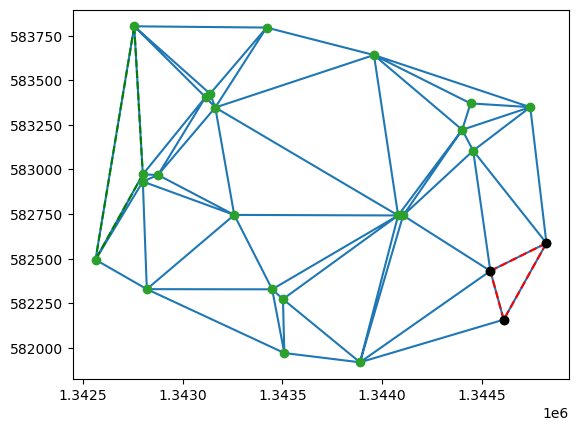

In [21]:
# Alright lets make some web thicknesses then add them
from scipy.spatial import cKDTree
from scipy.spatial import Delaunay
import matplotlib.pyplot as plt

## Make well pairs

# Extract the coordinates of the points
t = wells.copy()
t.reset_index(inplace=True, drop=True)
points = t[['x27_26782','y27_26782'
           ]].values
# Perform Delaunay triangulation
tri = Delaunay(points)


plt.triplot(points[:,0], points[:,1], tri.simplices)
plt.triplot(points[:,0], points[:,1], tri.simplices[0:1],c='r',linestyle='--')
plt.triplot(points[:,0], points[:,1], tri.simplices[1:2],c='g',linestyle='--')

plt.plot(points[:,0], points[:,1], 'o')

for pi in tri.simplices[0:1]:
    print(pi)
    plt.plot(points[:,0][pi], points[:,1][pi], 'o',c='k')
    #break

plt.show()

In [22]:
wellpairs = []
for (i0,i1,i2) in tri.simplices:

    n0 = t.at[i0,'Well_No']
    n1 = t.at[i1,'Well_No']
    n2 = t.at[i2,'Well_No']
    tpairs = [[n0,n1],[n1,n2],[n2,n0]]
    tpairs = [sorted(x) for x in tpairs]
    tpairs = [x for x in tpairs if x not in wellpairs]
    wellpairs = wellpairs + tpairs

sorted(wellpairs)

[['BLM001', 'BLM002'],
 ['BLM001', 'BLM003'],
 ['BLM001', 'BLM005'],
 ['BLM001', 'LGS002'],
 ['BLM001', 'VISTA1A'],
 ['BLM002', 'BLM004'],
 ['BLM002', 'BLM005'],
 ['BLM002', 'LGS002'],
 ['BLM002', 'PPG004'],
 ['BLM003', 'BLM005'],
 ['BLM003', 'PPG016'],
 ['BLM003', 'PPG020'],
 ['BLM003', 'VISTA1A'],
 ['BLM004', 'BLM005'],
 ['BLM004', 'PPG004'],
 ['LGS001', 'PPG007A'],
 ['LGS001', 'PPG007B'],
 ['LGS001', 'PPG021'],
 ['LGS001', 'SMSA1'],
 ['LGS002', 'LGS002A'],
 ['LGS002', 'PPG004'],
 ['LGS002', 'VISTA1A'],
 ['LGS002A', 'PPG002'],
 ['LGS002A', 'PPG002A'],
 ['LGS002A', 'PPG004'],
 ['LGS002A', 'PPG006Z'],
 ['LGS002A', 'PPG016'],
 ['LGS002A', 'PPG022'],
 ['LGS002A', 'VISTA1A'],
 ['PPG002', 'PPG002A'],
 ['PPG002', 'PPG005'],
 ['PPG002', 'PPG022'],
 ['PPG002', 'SMSA1'],
 ['PPG002A', 'PPG004'],
 ['PPG002A', 'PPG005'],
 ['PPG004', 'PPG005'],
 ['PPG005', 'SMSA1'],
 ['PPG006X', 'PPG006Y'],
 ['PPG006X', 'PPG006Z'],
 ['PPG006X', 'PPG018'],
 ['PPG006X', 'PPG021'],
 ['PPG006Y', 'PPG006Z'],
 ['PPG006Y

In [23]:
## Add TOS neighbors
 #<fck
saltneighbors = ['PPG018','PPG016','BLM003','VISTA1a','BLM005','BLM002','BLM004','PPG004','PPG005','PPG002A','PPG002',
                 'PPG021','SMSA1','LGS1','PPG007A','PPG007B','PPG007C','PPG006X','PPG006Y','PPG006Z',]


<Axes: >

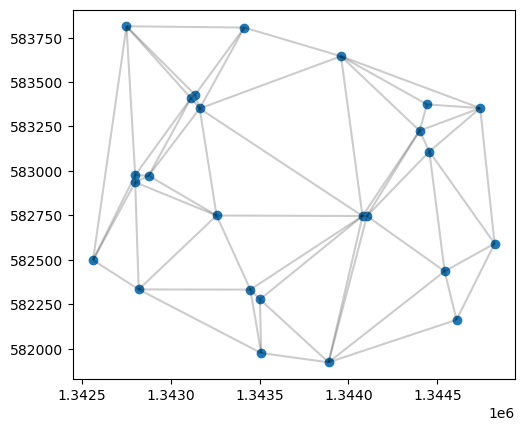

In [24]:
## Double Check Well Pairs Visually
pd.set_option('display.max_columns',None)
lines = []
## Check pairs
for w0,w1 in wellpairs:
    p0 = t[t.Well_No == w0].geometry.values[0]
    p1 = t[t.Well_No == w1].geometry.values[0]
    l = LineString([p0,p1])
    lines.append(l)
ax = gpd.GeoDataFrame({'geometry':lines}).plot(color='k', alpha=0.2)
gpd.GeoDataFrame(wells).plot(ax=ax)

In [25]:
## Functions
from skimage.draw import line_nd
import scipy
import pymeshfix as mf
from scipy.spatial import cKDTree
import itertools
from operator import itemgetter

def ckdnearest(gdfA, gdfB, gdfB_cols=['Place']):
    '''
    For finding nearest neighbors between point clouds.
    '''
    gdfB['geometry1'] = gdfB.geometry
    gdfB_cols.append('geometry1')



    A = np.concatenate(
        [np.array(geom.coords) for geom in gdfA.geometry.to_list()])
    B = [np.array(geom.coords) for geom in gdfB.geometry.to_list()]

    # Index values of gdfB
    B_ix = tuple(itertools.chain.from_iterable(
        [itertools.repeat(i, x) for i, x in enumerate(list(map(len, B)))]))
    B = np.concatenate(B)
    ckd_tree = cKDTree(B)
    dist, idx = ckd_tree.query(A, k=1)
    idx = itemgetter(*idx)(B_ix)
    gdf = pd.concat(
        [gdfA, gdfB.loc[idx, gdfB_cols].reset_index(drop=True),
         pd.Series(dist, name='dist')], axis=1)
    
    # Nearest Line
    i = gdf[gdf.dist == gdf.dist.min()].index.values[0]
    p0,p1 = gdf.at[i,'geometry'], gdf.at[i,'geometry1']
    if isinstance(p1,Point):
        pass
    elif len(list(p1)) > 1:
        p1 = p1[0]
    line = gpd.GeoDataFrame({'geometry':[LineString([p0,p1])],
                             'distance':[gdf.dist.min()]},
                           crs=gdfA.crs)
    return line

In [ ]:
import pandas as pd
import geopandas as gpd
import pyvista as pv
from shapely import Point

crs = 'EPSG:26782'
# one off fix
# path = r"Z:\Louisiana DNR 1138\3.0 Analysis\python_inputs\stl\BLM005_202320906_mwb_approx_ref.stl"
path = r"Z:\Louisiana DNR 1138\3.0 Analysis\python_inputs\stl\PPG002_20250108_FinalSonar_georef_moved.stl"

p = pv.read(path)
pnts = p.points
geom = [Point(p) for p in pnts]
gdf = gpd.GeoDataFrame({'geometry':geom}, crs=crs)
# outpath = r"Z:\Louisiana DNR 1138\3.0 Analysis\python_inputs\gpkg\pntclouds\BLM005_202320906_mwb_approx_ref.gpkg"
outpath = r"Z:\Louisiana DNR 1138\3.0 Analysis\python_inputs\gpkg\pntclouds\PPG002_20250108_FinalSonar_georef.gpkg"
gdf.to_file(outpath)


df = pd.read_excel(r"Z:\Louisiana DNR 1138\3.0 Analysis\python\Point_Cloud_search_mwb202607.xlsx")
df.head(2)

In [3]:
# Pre-load
for index, row in df[df.path.notnull()].iterrows():
    path = row['path']
    print(path)
    continue
    gdf = gpd.read_file(path)
    if gdf.crs != crs:
        gdf.to_crs(crs, inplace=True)
        print('crs')
    df.at[index,'pnts']  = gdf
    print('.', end='')

Z:\Louisiana DNR 1138\3.0 Analysis\python_inputs\gpkg\pntclouds\BLM1_20200205_26782.gpkg
Z:\Louisiana DNR 1138\3.0 Analysis\python_inputs\gpkg\pntclouds\BLM002_20240516_26782.gpkg
Z:\Louisiana DNR 1138\3.0 Analysis\python_inputs\gpkg\pntclouds\FINAL SONAR REPORT - Boardwalk No. 3 - March 9, 2021_26782.gpkg
Z:\Louisiana DNR 1138\3.0 Analysis\python_inputs\gpkg\pntclouds\BLM004_20240408_26782.gpkg
Z:\Louisiana DNR 1138\3.0 Analysis\python_inputs\gpkg\pntclouds\BLM005_202320906_mwb_approx_ref.gpkg
Z:\Louisiana DNR 1138\3.0 Analysis\python_inputs\gpkg\pntclouds\LGS1_20070111_26782.gpkg
Z:\Louisiana DNR 1138\3.0 Analysis\python_inputs\gpkg\pntclouds\LGS2_20080407_26782.gpkg
Z:\Louisiana DNR 1138\3.0 Analysis\python_inputs\stl\PPG002_20250108_FinalSonar .stl
Z:\Louisiana DNR 1138\3.0 Analysis\python_inputs\gpkg\pntclouds\PPG004_20250828_26782.gpkg
Z:\Louisiana DNR 1138\3.0 Analysis\python_inputs\gpkg\pntclouds\1993_SPR2_synthetic_v2_EPSG26782.gpkg
Z:\Louisiana DNR 1138\3.0 Analysis\python_in

In [48]:
df

,Old_name,Well_Name,Well_No,Most_Recent_Sonris_Sonar_Date,Unnamed: 4,Most recent STL File Path (.stl included),Deviation File Path (.gpkg excluded),Unnamed: 7,Status,Status.1,Serial_No,API,x27_26782,y27_26782,x83_26915,y83_26915,long_4326,lat_4326,z,Source,dt,yyyy,mm,path,Unnamed: 24,Sonar Src File,Unnamed: 26,pnts
0,BLM001,SULPHUR STORAGE,001,2020-02-05 00:00:00,Z:\Louisiana DNR 1138\3.0 Analysis\data\Sulphu...,Z:\Louisiana DNR 1138\3.0 Analysis\python_inpu...,NaN,NaN,Active Injection,9,973525,17019880980000,1344456,583105,460570.280441,3.347006e+06,-93.409872,30.254040,11.00,https://sonlite.dnr.state.la.us/ords/r/sonris_...,2025-02-04,2020.0,2.0,Z:\Louisiana DNR 1138\3.0 Analysis\python_inpu...,"2025 sonar is partial and through Pipe, using ...",NaN,NaN,NaN
1,BLM002,SULPHUR STORAGE,002,5/16/2024,Z:\Louisiana DNR 1138\3.0 Analysis\data\Sulphu...,Z:\Louisiana DNR 1138\3.0 Analysis\python_inpu...,NaN,NaN,Active Injection,9,33058,17019031960000,1344542,582431,460599.468545,3.346801e+06,-93.409561,30.252191,8.10,https://sonlite.dnr.state.la.us/ords/r/sonris_...,2024-05-16,2024.0,5.0,Z:\Louisiana DNR 1138\3.0 Analysis\python_inpu...,"voxel stl in folder, don't see save point cloud",Z:\Louisiana DNR 1138\3.0 Analysis\data\Sulphu...,NaN,depth tilt cAzi r cAziN...
2,BLM003?,SULPHUR STORAGE,003,4/9/2021,Z:\Louisiana DNR 1138\3.0 Analysis\data\Sulphu...,Z:\Louisiana DNR 1138\3.0 Analysis\python_inpu...,Z:\Louisiana DNR 1138\3.0 Analysis\data\Sulphu...,2021-09-03 00:00:00,Active Injection,9,236863,17019222050000,1344742,583349,460656.334728,3.347082e+06,-93.408981,30.254725,13.70,https://sonlite.dnr.state.la.us/ords/r/sonris_...,2021-04-09,2021.0,3.0,Z:\Louisiana DNR 1138\3.0 Analysis\python_inpu...,NaN,NaN,NaN,depth tilt vos range cAzi r ...
3,BLM003,UNDERGROUND STORAGE N,003,10/14/2025,Z:\Louisiana DNR 1138\3.0 Analysis\data\Underg...,NaN,NaN,14/10/2025,Active Injection,9,138983,17047202470000,2008234,601127,662738.000000,3.355448e+06,-91.307352,30.319915,NaN,NaN,2025-10-14,2025.0,10.0,NaN,Havent found the 2025 file; assuming the 2021 ...,NaN,NaN,NaN
4,BLM004,SULPHUR STORAGE,004,4/8/2024,Z:\Louisiana DNR 1138\3.0 Analysis\data\Sulphu...,"""Z:\Louisiana DNR 1138\3.0 Analysis\python_inp...",NaN,NaN,Active Injection,9,974675,17019881560000,1344609,582158,460621.091087,3.346718e+06,-93.409333,30.251444,12.10,https://sonlite.dnr.state.la.us/ords/r/sonris_...,2024-04-08,2024.0,4.0,Z:\Louisiana DNR 1138\3.0 Analysis\python_inpu...,<2018 is the wrong date,NaN,NaN,geometr...
5,BLM005,SULPHUR STORAGE,005,9/6/2023,Z:\Louisiana DNR 1138\3.0 Analysis\data\Sulphu...,Z:\Louisiana DNR 1138\3.0 Analysis\python_inpu...,NaN,NaN,Active Injection,9,974894,17019881900000,1344823,582587,460684.389403,3.346850e+06,-93.408680,30.252634,13.90,https://sonlite.dnr.state.la.us/ords/r/sonris_...,2023-09-06,2023.0,9.0,Z:\Louisiana DNR 1138\3.0 Analysis\python_inpu...,NaN,NaN,NaN,NaN
6,LGS001,LIBERTY GAS STORAGE,001,1/11/2007,Z:\Louisiana DNR 1138\3.0 Analysis\data\Libert...,Z:\Louisiana DNR 1138\3.0 Analysis\python_inpu...,Z:\Louisiana DNR 1138\3.0 Analysis\data\Libert...,25/06/1979,Dry and Plugged,29,163676,17019208460000,1342564,582494,459996.553069,3.346812e+06,-93.415829,30.252266,15.81,https://sonlite.dnr.state.la.us/ords/r/sonris_...,2007-01-11,2007.0,1.0,Z:\Louisiana DNR 1138\3.0 Analysis\python_inpu...,NaN,NaN,NaN,NaN
7,LGS002,LIBERTY GAS STORAGE,002,4/7/2008,Z:\Louisiana DNR 1138\3.0 Analysis\data\Libert...,Z:\Louisiana DNR 1138\3.0 Analysis\python_inpu...,NaN,NaN,Dry and Plugged,29,163678,17019208480000,1344105,582742,460464.949931,3.346894e+06,-93.410963,30.253025,4.95,https://sonlite.dnr.state.la.us/ords/r/sonris_...,2008-04-07,2008.0,4.0,Z:\Louisiana DNR 1138\3.0 Analysis\python_inpu...,NaN,NaN,NaN,NaN
8,LGS002A,LIBERTY GAS STORAGE,002A,None in SONRIS,Z:\Louisiana DNR 1138\3.0 Analysis\data\Libert...,NaN,Z:\Louisiana DNR 1138\3.0 Analysis\data\Libert...,20/02/2015,Dry and Plugged,29,973478,17019880960000,1344080,582742,460457.333194,3.346894e+06,-93.41

In [44]:
for w0,w1 in wellpairs:
    p0 = df[(df.Old_name == w0)&(df.path.notnull())]['path'].tolist()
    p1 = df[(df.Old_name == w1)&(df.path.notnull())]['path'].tolist()
    
    if p0 and p1:
        print('.', end='')
        gdfA = gpd.read_file(p0[0])
        gdfB
    else:
        print('skip', w0,w1, end='\n')


......skip PPG006Z PPG016
skip LGS002A PPG006Z
skip LGS002A PPG016
skip PPG006Z PPG018
.skip PPG006Z PPG022
skip LGS002A PPG022
skip PPG006Z PPG007C
.......skip PPG007A SMSA1
skip LGS001 SMSA1
.skip PPG022 SMSA1
.skip LGS002 LGS002A
skip LGS002A PPG004
..skip LGS002A VISTA1A
...skip BLM003 VISTA1A
skip BLM003 PPG020
skip BLM003 PPG016
...skip PPG006X PPG006Z
.skip LGS002A PPG002
skip PPG002 SMSA1
skip PPG005 SMSA1
.....skip BLM001 BLM003
skip BLM003 BLM005
....skip PPG006Y PPG006Z
skip PPG002A PPG004
skip PPG002A PPG005
.skip PPG002 PPG002A
skip LGS002A PPG002A


In [74]:
paths = df[df.Old_name.isin(names)]['Most recent STL File Path (.stl included)'].tolist()
paths

['Z:\\Louisiana DNR 1138\\3.0 Analysis\\python_inputs\\stl\\BLM002_20240516.stl',
 'Z:\\Louisiana DNR 1138\\3.0 Analysis\\python_inputs\\stl\\BLM004_201805.stl']

In [77]:
print(wells.crs)

EPSG:26782


,geometry
0,POINT Z (1344554.875 582435.75 -2265.799)
1,POINT Z (1344555.875 582434.75 -2265.799)
2,POINT Z (1344555.875 582435.75 -2265.799)
3,POINT Z (1344554.875 582434.75 -2265.799)
4,POINT Z (1344553.875 582435.75 -2265.799)
...,...
178333,POINT Z (1344552.875 582432.75 -2836.799)
178334,POINT Z (1344555.875 582431.75 -2836.799)
178335,POINT Z (1344554.875 582431.75 -2836.799)
178336,POINT Z (1344553.875 582431.75 -2836.799)


In [99]:
lines2 = pd.DataFrame()
lines2['label'] = ''

0

..............not enough values to unpack (expected 2, got 1)
not enough values to unpack (expected 2, got 1)
.not enough values to unpack (expected 2, got 1)
..........not enough values to unpack (expected 2, got 1)
not enough values to unpack (expected 2, got 1)
..........

AttributeError: 'DataFrame' object has no attribute 'to_file'

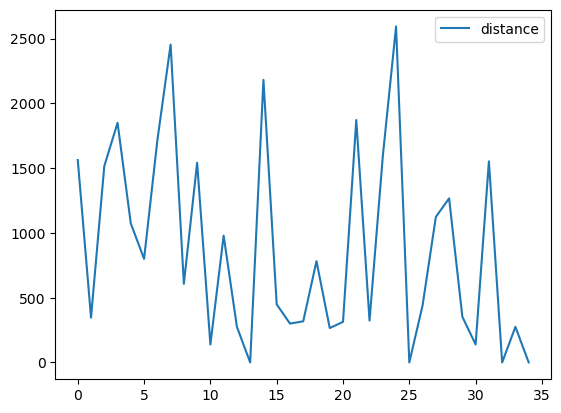

In [104]:
import time
t0 = time.time()

# ci=1
for names in wellpairs:
    #intermediate statues check
    # if ci >= len(lines2):
    #     print('*',end='')
    #     continue
    # ci+=1
    
    paths = df[df.Old_name.isin(names)]['Most recent STL File Path (.stl included)'].tolist()
    paths = [str(x) for x in paths]
    if 'nan' in paths:
        continue
    #dts = [x.strftime('%Y%m%d') for x in t[t.Well_No.isin(names)].datetime.tolist()]
    wellnames =  df[df.Old_name.isin(names)]['Old_name'].tolist()
    label = '_'.join(sorted(wellnames))
    if label in lines2.label.values:
        print('*', end='')
        continue
    #paths = [p[:-1*p[::-1].index('/')]+'pointcloud/' + w + '_' + t +'.shp' for p,t,w in zip(paths,dts,wells)]
    
    #gdfA, gdfB = [gpd.read_file(x) for x in paths]
    try:
        a0, a1 = df[df.Old_name.isin(names)]['a'].tolist()
        gdfA = gpd.GeoDataFrame(geometry=[Point(p) for p in a0], crs='EPSG:26782')
        gdfB = gpd.GeoDataFrame(geometry=[Point(p) for p in a1], crs='EPSG:26782')
        
        # Find nearest 3D neighbor
        line = ckdnearest(gdfA, gdfB, gdfB_cols=[])
        line['label'] = label
        lines2 = pd.concat([lines2,line], ignore_index=True)
        print('.',end='')
    except Exception as e:
        print(e)
        pass

lines2.drop_duplicates(inplace=True,keep='first')
lines2.plot()
lines2.to_file('lines.shp')

t1 = time.time()
print((t1-t0)/60, 'min for',lines2.shape[0],'wellpairs.')

In [105]:
lines2

,label,geometry,distance
0,BLM002_BLM004,"LINESTRING Z (1344564.875 582411.75 -2833.799,...",1562.952822
1,BLM004_BLM005,LINESTRING Z (1344610.046 582245.952 -6120.424...,346.183440
2,BLM002_BLM005,"LINESTRING Z (1344577.875 582464.75 -2832.799,...",1516.068414
3,PPG007B_PPG021,LINESTRING Z (1342779.125 583141.375 -3127.668...,1850.609000
4,LGS001_PPG021,"LINESTRING Z (1342605.75 582739.562 -4557.292,...",1072.815422
5,LGS001_PPG007B,"LINESTRING Z (1342566.125 582497.25 -3876.81, ...",800.215839
6,PPG016_PPG018,"LINESTRING Z (1343845.5 583724.312 -3500.286, ...",1713.473255
7,PPG007C_PPG022,"LINESTRING Z (1342739.68 583056.727 -3119.364,...",2454.623767
8,BLM002_PPG004,"LINESTRING Z (1344504.875 582395.75 -2798.799,...",607.062053
9,BLM004_PPG004,"LINESTRING Z (1344620.134 582163.75 -4376.473,...",1541.995903


In [107]:
# To TOS
path = basepath + "/python_inputs/stl/TOS_fixed_normals.stl"
tosfull = pv.read(path).points
gdfA = gpd.GeoDataFrame(geometry=[Point(p) for p in tosfull], crs='EPSG:26782')

pyvista_ndarray([[1343585.80043024,  581805.48926192,   -1456.98259726],
                 [1343918.29075291,  581926.22641753,   -1412.86083552],
                 [1343582.92947428,  582219.75745493,   -1459.39397557],
                 ...,
                 [1340708.5       ,  581665.        ,   -7750.01513672],
                 [1342367.07485722,  582727.1954617 ,   -2023.30137287],
                 [1342304.58590026,  582792.68894488,   -2742.05519776]],
                shape=(10841, 3))

In [90]:
print(names)
df[df.Old_name.isin(names)]

['PPG007A', 'SMSA1']


,Old_name,Well_Name,Well_No,Most_Recent_Sonris_Sonar_Date,Unnamed: 4,Most recent STL File Path (.stl included),Deviation File Path (.gpkg excluded),Unnamed: 7,Status,Status.1,...,API,x27_26782,y27_26782,x83_26915,y83_26915,long_4326,lat_4326,z,Source,a
16,PPG007A,PPG,007A,5/24/2018,Z:\Louisiana DNR 1138\3.0 Analysis\data\PPG 7A...,Z:\Louisiana DNR 1138\3.0 Analysis\python_inpu...,Z:\Louisiana DNR 1138\3.0 Analysis\data\PPG 7A...,24/05/2018,Dry and Plugged,29,...,17019040110000,1342801,582932,460066.818967,3.346946e+06,-93.415103,30.253482,12.8,https://sonlite.dnr.state.la.us/ords/r/sonris_...,"[[1343424.005282745, 583422.6046123289, -3275...."


In [47]:
wells[wells.Well_No.str.contains('005')]#[['x27_26782','y27_26782']].values

,Well_No,SerialNo,API,x27_26782,y27_26782,x83_26915,y83_26915,long_4326,lat_4326,z,Source,geometry
4,BLM005,974894,17019881900000,1344823,582587,460684.389403,3.346850e+06,-93.408680,30.252634,13.9,https://sonlite.dnr.state.la.us/ords/r/sonris_...,POINT Z (1344821.862 582590.873 13.9)
11,PPG005,47444,17019040080000,1343510,581971,460287.087946,4.602871e+05,-93.412803,30.250875,0.0,https://sonlite.dnr.state.la.us/ords/r/sonris_...,POINT Z (1343508.862 581974.867 0)


In [173]:
pl = pv.Plotter()
path = r"C:\Users\bauer\Pictures\LA_DENR_Logo.svg"
a = svg_to_contours(path)

# Bounds
c = list(a.values())
c = [item for sublist in c for item in sublist]
c = np.concatenate(c)
xmax = c[:,0].max()#max([p[:,0].max() for p in c])
xmin = c[:,0].min()#min([p[:,0].min() for p in c])
ymax = c[:,1].max()#max([p[:,1].max() for p in c])
ymin = c[:,1].min()#min([p[:,1].min() for p in c])
dx = xmax - xmin
dy = ymax - ymin

scale = 100
x0, y0, z0 = ll
x0 += 500

origin = np.array([x0, y0, z0])

i = 0
dz = -50
for color, contours in a.items():
    for pc in contours:
        
        #break
        # print(contours.shape)
        p = pc.copy()
        # Add Z axis
        p = np.column_stack((p, np.full(len(p), i*dz)))#
        p[:,0] -= xmin
        p[:,0] /= dx
        p[:,1] -= ymin
        p[:,1] /= dy
        p *= scale
        p += [origin]
        #layeroffset = np.array([0,0,])
        #p += [offset]
        i +=1
        #for ps in p:
        p = simplify3d(p, scale/500)
        line_source = pv.MultipleLines( points=p )
        pl.add_mesh(line_source, color=color,line_width=2)
    #break

pl.show()

Widget(value='<iframe src="http://localhost:64290/index.html?ui=P_0x273f71bd210_39&reconnect=auto" class="pyvi…

In [ ]:
p

In [172]:
print(p.shape)
p = simplify3d(p, scale/100)
p.shape

(81, 3)


(2, 3)

In [164]:
for p in c:
    print(p.shape)

AttributeError: 'list' object has no attribute 'shape'

In [145]:
for color, contours in a.items():
    print(color,len(contours))
    for p in contours[:10]:
        print('\t',p.shape)

#8cccee 27
	 (21, 2)
	 (21, 2)
	 (21, 2)
	 (21, 2)
	 (21, 2)
	 (21, 2)
	 (21, 2)
	 (21, 2)
	 (21, 2)
	 (21, 2)
#d5af7a 685
	 (21, 2)
	 (21, 2)
	 (21, 2)
	 (21, 2)
	 (21, 2)
	 (21, 2)
	 (21, 2)
	 (21, 2)
	 (21, 2)
	 (21, 2)
#211e1f 76
	 (21, 2)
	 (21, 2)
	 (21, 2)
	 (21, 2)
	 (21, 2)
	 (21, 2)
	 (21, 2)
	 (21, 2)
	 (21, 2)
	 (21, 2)
#a05c23 190
	 (21, 2)
	 (21, 2)
	 (21, 2)
	 (21, 2)
	 (21, 2)
	 (21, 2)
	 (21, 2)
	 (21, 2)
	 (21, 2)
	 (21, 2)
#218ac9 144
	 (21, 2)
	 (21, 2)
	 (21, 2)
	 (21, 2)
	 (21, 2)
	 (21, 2)
	 (21, 2)
	 (21, 2)
	 (21, 2)
	 (21, 2)
#126652 267
	 (21, 2)
	 (21, 2)
	 (21, 2)
	 (21, 2)
	 (21, 2)
	 (21, 2)
	 (21, 2)
	 (21, 2)
	 (21, 2)
	 (21, 2)
#80b98d 553
	 (21, 2)
	 (21, 2)
	 (21, 2)
	 (21, 2)
	 (21, 2)
	 (21, 2)
	 (21, 2)
	 (21, 2)
	 (21, 2)
	 (21, 2)
#f0a533 1474
	 (21, 2)
	 (21, 2)
	 (21, 2)
	 (21, 2)
	 (21, 2)
	 (21, 2)
	 (21, 2)
	 (21, 2)
	 (21, 2)
	 (21, 2)
#0c5a92 973
	 (21, 2)
	 (21, 2)
	 (21, 2)
	 (21, 2)
	 (21, 2)
	 (21, 2)
	 (21, 2)
	 (21, 2)
	 (21, 2)
	 (

In [146]:
p

array([[ 64.87309   , 304.66402   ],
       [ 65.00715135, 304.5951575 ],
       [ 65.1412127 , 304.526295  ],
       [ 65.27527405, 304.4574325 ],
       [ 65.4093354 , 304.38857   ],
       [ 65.54339675, 304.3197075 ],
       [ 65.6774581 , 304.250845  ],
       [ 65.81151945, 304.1819825 ],
       [ 65.9455808 , 304.11312   ],
       [ 66.07964215, 304.0442575 ],
       [ 66.2137035 , 303.975395  ],
       [ 66.34776485, 303.9065325 ],
       [ 66.4818262 , 303.83767   ],
       [ 66.61588755, 303.7688075 ],
       [ 66.7499489 , 303.699945  ],
       [ 66.88401025, 303.6310825 ],
       [ 67.0180716 , 303.56222   ],
       [ 67.15213295, 303.4933575 ],
       [ 67.2861943 , 303.424495  ],
       [ 67.42025565, 303.3556325 ],
       [ 67.554317  , 303.28677   ]])

In [119]:
p = contours.copy()
# Add Z axis
p = [np.column_stack((x, np.full(len(x), 0))) for x in p]#
contours,p

(array([[ 61.107418  , 156.13587   ],
        [ 60.79195166, 156.02969381],
        [ 60.43062507, 155.91877799],
        ...,
        [ 61.107418  , 156.13587   ],
        [ 61.107418  , 156.13587   ],
        [ 61.107418  , 156.13587   ]], shape=(541, 2)),
 [array([[ 61.107418,   0.      ],
         [156.13587 ,   0.      ]]),
  array([[ 60.79195166,   0.        ],
         [156.02969381,   0.        ]]),
  array([[ 60.43062507,   0.        ],
         [155.91877799,   0.        ]]),
  array([[ 60.02675227,   0.        ],
         [155.80378965,   0.        ]]),
  array([[ 59.58364726,   0.        ],
         [155.68539592,   0.        ]]),
  array([[ 59.10462406,   0.        ],
         [155.56426391,   0.        ]]),
  array([[ 58.5929967 ,   0.        ],
         [155.44106073,   0.        ]]),
  array([[ 58.0520792 ,   0.        ],
         [155.31645351,   0.        ]]),
  array([[ 57.48518557,   0.        ],
         [155.19110936,   0.        ]]),
  array([[ 56.89562983,   0. 

In [110]:
contours

array([[ 61.107418  , 156.13587   ],
       [ 60.79195166, 156.02969381],
       [ 60.43062507, 155.91877799],
       ...,
       [ 61.107418  , 156.13587   ],
       [ 61.107418  , 156.13587   ],
       [ 61.107418  , 156.13587   ]], shape=(541, 2))

In [35]:
dipstick
for x in dipstick:
    print(x,'\n')

[1343692.3609135908, 582868.0402258257, np.float64(-1500.0)] 

[1343692.3609135908, 582868.0402258257, np.float64(-250.0)] 

[[1343692.3609135908, 582868.0402258257, np.float64(-1500.0)], [1343717.3609135908, 582868.0402258257, np.float64(-1500.0)]] 

[[1343692.3609135908, 582868.0402258257, np.float64(-1250.0)], [1343717.3609135908, 582868.0402258257, np.float64(-1250.0)]] 

[[1343692.3609135908, 582868.0402258257, np.float64(-1000.0)], [1343717.3609135908, 582868.0402258257, np.float64(-1000.0)]] 

[[1343692.3609135908, 582868.0402258257, np.float64(-750.0)], [1343717.3609135908, 582868.0402258257, np.float64(-750.0)]] 

[[1343692.3609135908, 582868.0402258257, np.float64(-500.0)], [1343717.3609135908, 582868.0402258257, np.float64(-500.0)]] 

[[1343692.3609135908, 582868.0402258257, np.float64(-250.0)], [1343717.3609135908, 582868.0402258257, np.float64(-250.0)]] 



In [84]:
for k,v in xyz1d.items():
    #break
    xyz1d[k] = [float(p) for p in v]

In [85]:
xyz1d

{'BLM001': [1344486.0074834202, 583062.5575223526, -1157.9002685546875],
 'BLM002': [1344554.875, 582434.75, -2265.798583984375],
 'Unknown': [1344734.2910187866, 583349.4276416217, -1252.00244140625],
 'BLM004': [1344620.134093553, 582163.7503640393, -1333.9488525390625],
 'LGS001': [1342546.7450631661, 582513.0424976617, -1181.6451416015625],
 'LGS002': [1344064.1585485379, 582746.2056278693, -733.9623413085938],
 'PPG002': [1343455.25, 582333.5625, -1849.12841796875],
 'PPG004': [1343886.0581683933, 581917.5751081853, -546.5888671875],
 'PPG005': [1343502.385851897, 581966.633888878, -622.4263916015625],
 'PPG006X': [1343130.4497198237, 583421.3040341364, -800.0744018554688],
 'PPG006Y': [1343106.6940281796, 583453.4683342458, -909.388427734375],
 'PPG007A': [1343106.6940281796, 583453.4683342458, -909.388427734375],
 'PPG007B': [1342794.0, 582979.5625, -2774.670654296875],
 'PPG007C': [1342747.4797407326, 583017.3341436131, -763.791748046875],
 'PPG016': [1344002.75, 583685.875, -2

In [68]:
lines

,MD,AZI,INC,E,N,TVD,API,x,y,z,geometry,name
0,0.0,0.0,0.0,0.0,0.0,0.0,17019222050000,1344742.0,583349.0,13.70,"LINESTRING Z (1344742 583349 13.7, 1344742 583...",BLM003
1,0.0,0.0,0.0,0.0,0.0,0.0,17019208460000,1342564.0,582494.0,15.81,"LINESTRING Z (1342564 582494 15.81, 1342564.00...",LGS001
2,0.0,0.0,0.0,0.0,0.0,0.0,17019880960000,1344080.0,582742.0,0.00,"LINESTRING Z (1344080 582742 0, 1344080 582742...",LGS002A
3,0.0,0.0,0.0,0.0,0.0,0.0,17019880380000,1343503.0,582273.0,11.40,"LINESTRING Z (1343503 582273 11.4, 1343503 582...",PPG002A
4,0.0,0.0,0.0,0.0,0.0,0.0,17019208470000,1343959.0,583641.0,0.00,"LINESTRING Z (1343959 583641 0, 1343959 583641...",PPG016
5,0.0,0.0,0.0,0.0,0.0,0.0,17019040090000,1343138.0,583424.0,12.00,"LINESTRING Z (1343138 583424 12, 1343138 58342...",PPG6X
6,0.0,0.0,0.0,0.0,0.0,0.0,17019040110000,1342801.0,582932.0,12.80,"LINESTRING Z (1342801 582932 12.8, 1342801 582...",PPG7A
7,0.0,0.0,0.0,0.0,0.0,0.0,17019040120000,1342801.0,582972.0,12.60,"LINESTRING Z (1342801 582972 12.6, 1342801 582...",PPG7B
8,0.0,0.0,0.0,0.0,0.0,0.0,17019880400000,1342877.0,582969.0,12.43,"LINESTRING Z (1342877 582969 12.43, 1342877 58...",PPG7C
9,0.0,0.0,0.0,0.0,0.0,0.0,17019206040000,1342821.0,582329.0,0.00,"LINESTRING Z (1342821 582329 0, 1342821 582329...",PPGA1


In [44]:
path = df.at[9,'Most recent STL File Path (.stl included)']
print(path)
a = pv.read(path)
print(a.points[0])
wells.head()

Z:\Louisiana DNR 1138\3.0 Analysis\python_inputs\stl\PPG002_20250108_FinalSonar .stl
[    0.       0.   -1849.81]


,Well_No,SerialNo,API,x27_26782,y27_26782,x83_26915,y83_26915,long_4326,lat_4326,z,Source,geometry
0,BLM001,973525,17019880980000,1344456,583105,460570.280441,3.347006e+06,-93.409872,30.254040,11.0,https://sonlite.dnr.state.la.us/ords/r/sonris_...,POINT Z (1344454.863 583108.872 11)
1,BLM002,33058,17019031960000,1344542,582431,460599.468545,3.346801e+06,-93.409561,30.252191,8.1,https://sonlite.dnr.state.la.us/ords/r/sonris_...,POINT Z (1344540.863 582434.871 8.1)
2,BLM003,236863,17019222050000,1344742,583349,460656.334728,3.347082e+06,-93.408981,30.254725,13.7,https://sonlite.dnr.state.la.us/ords/r/sonris_...,POINT Z (1344740.861 583352.872 13.7)
3,BLM004,974675,17019881560000,1344609,582158,460621.091087,3.346718e+06,-93.409333,30.251444,12.1,https://sonlite.dnr.state.la.us/ords/r/sonris_...,POINT Z (1344607.862 582161.872 12.1)
4,BLM005,974894,17019881900000,1344823,582587,460684.389403,3.346850e+06,-93.408680,30.252634,13.9,https://sonlite.dnr.state.la.us/ords/r/sonris_...,POINT Z (1344821.862 582590.873 13.9)


In [45]:
lines

,MD,AZI,INC,E,N,TVD,API,x,y,z,geometry,name
0,0.0,0.0,0.0,0.0,0.0,0.0,17019222050000,1344742.0,583349.0,13.70,"LINESTRING Z (1344742 583349 13.7, 1344742 583...",BLM003
1,0.0,0.0,0.0,0.0,0.0,0.0,17019208460000,1342564.0,582494.0,15.81,"LINESTRING Z (1342564 582494 15.81, 1342564.00...",LGS001
2,0.0,0.0,0.0,0.0,0.0,0.0,17019880960000,1344080.0,582742.0,0.00,"LINESTRING Z (1344080 582742 0, 1344080 582742...",LGS002A
3,0.0,0.0,0.0,0.0,0.0,0.0,17019880380000,1343503.0,582273.0,11.40,"LINESTRING Z (1343503 582273 11.4, 1343503 582...",PPG002A
4,0.0,0.0,0.0,0.0,0.0,0.0,17019208470000,1343959.0,583641.0,0.00,"LINESTRING Z (1343959 583641 0, 1343959 583641...",PPG016
5,0.0,0.0,0.0,0.0,0.0,0.0,17019040090000,1343138.0,583424.0,12.00,"LINESTRING Z (1343138 583424 12, 1343138 58342...",PPG6X
6,0.0,0.0,0.0,0.0,0.0,0.0,17019040110000,1342801.0,582932.0,12.80,"LINESTRING Z (1342801 582932 12.8, 1342801 582...",PPG7A
7,0.0,0.0,0.0,0.0,0.0,0.0,17019040120000,1342801.0,582972.0,12.60,"LINESTRING Z (1342801 582972 12.6, 1342801 582...",PPG7B
8,0.0,0.0,0.0,0.0,0.0,0.0,17019880400000,1342877.0,582969.0,12.43,"LINESTRING Z (1342877 582969 12.43, 1342877 58...",PPG7C
9,0.0,0.0,0.0,0.0,0.0,0.0,17019206040000,1342821.0,582329.0,0.00,"LINESTRING Z (1342821 582329 0, 1342821 582329...",PPGA1


In [39]:
p={'BLM001 ' :[ 1.81914225e+05  ,4.18358302e+06 ,-1.15810791e+03],
'BLM002 ' :[ 1.3445549e+06,  5.8243575e+05, -2.2657986e+03],
'Unknown' :[ 1.81939144e+05  ,4.18360300e+06 ,-1.35396057e+03],
'BLM004 ' :[ 1.81930631e+05  ,4.18349934e+06 ,-2.03223254e+03],
'LGS001 ' :[ 1.81734759e+05  ,4.18353906e+06 ,-1.40002734e+03],
'LGS002 ' :[ 1.81884267e+05  ,4.18353315e+06 ,-1.07237085e+03],
'PPG002 ' :[ 5.33090037e+04  ,3.16302609e+06 ,-1.84981006e+03],
'PPG004 ' :[ 1.81872899e+05  ,4.18347798e+06 ,-9.05710876e+02],
'PPG005 ' :[ 1.81827716e+05  ,4.18347621e+06 ,-6.22426392e+02],
'PPG006X' :[ 1.81783128e+05  ,4.18358869e+06 ,-1.00447186e+03],
'PPG006Y' :[ 1.81817505e+05  ,4.18360950e+06 ,-9.98293579e+02],
'PPG007A' :[ 1.81817505e+05  ,4.18360950e+06 ,-9.98293579e+02],
'PPG007B' :[ 1.3427949e+06,  5.8298044e+05, -2.7746682e+03],
'PPG007C' :[ 1.81754038e+05  ,4.18357442e+06 ,-9.36612427e+02],
'PPG016 ' :[ 1.3440995e+06,  5.8358281e+05, -3.2469404e+03],
'PPG018 ' :[ 1.3434218e+06,  5.8378481e+05, -5.1652266e+03],
'PPG020 ' :[ 1.3444482e+06,  5.8336794e+05, -3.2999900e+03],
'PPG021 ' :[ 1.81746589e+05  ,4.18363360e+06 ,-1.73783447e+03],
'PPG022 ' :[ 1.3432644e+06 , 5.8273994e+05 ,-5.1798735e+03] ,
'VISTA1A' :[ 1.344823e+06,  5.825890e+05, -2.530000e+03],}
check = gpd.GeoDataFrame({'geometry':[Point(x) for x in list(p.values())]}, crs=26782)

[<POINT Z (181914.225 4183583.02 -1158.108)>,
 <POINT Z (1344554.9 582435.75 -2265.799)>,
 <POINT Z (181939.144 4183603 -1353.961)>,
 <POINT Z (181930.631 4183499.34 -2032.233)>,
 <POINT Z (181734.759 4183539.06 -1400.027)>,
 <POINT Z (181884.267 4183533.15 -1072.371)>,
 <POINT Z (53309.004 3163026.09 -1849.81)>,
 <POINT Z (181872.899 4183477.98 -905.711)>,
 <POINT Z (181827.716 4183476.21 -622.426)>,
 <POINT Z (181783.128 4183588.69 -1004.472)>,
 <POINT Z (181817.505 4183609.5 -998.294)>,
 <POINT Z (181817.505 4183609.5 -998.294)>,
 <POINT Z (1342794.9 582980.44 -2774.668)>,
 <POINT Z (181754.038 4183574.42 -936.612)>,
 <POINT Z (1344099.5 583582.81 -3246.94)>,
 <POINT Z (1343421.8 583784.81 -5165.227)>,
 <POINT Z (1344448.2 583367.94 -3299.99)>,
 <POINT Z (181746.589 4183633.6 -1737.834)>,
 <POINT Z (1343264.4 582739.94 -5179.874)>,
 <POINT Z (1344823 582589 -2530)>]

In [33]:
df.head()

,Old_name,Well_Name,Well_No,Most_Recent_Sonris_Sonar_Date,Unnamed: 4,Most recent STL File Path (.stl included),Deviation File Path (.gpkg excluded),Unnamed: 7,Status,Status.1,Serial_No,API,x27_26782,y27_26782,x83_26915,y83_26915,long_4326,lat_4326,z,Source
0,BLM001,SULPHUR STORAGE,001,2/4/2025,Z:\Louisiana DNR 1138\3.0 Analysis\data\Sulphu...,Z:\Louisiana DNR 1138\3.0 Analysis\python_inpu...,NaN,NaN,Active Injection,9,973525,17019880980000,1344456,583105,460570.280441,3.347006e+06,-93.409872,30.254040,11.0,https://sonlite.dnr.state.la.us/ords/r/sonris_...
1,BLM002,SULPHUR STORAGE,002,5/16/2024,Z:\Louisiana DNR 1138\3.0 Analysis\data\Sulphu...,Z:\Louisiana DNR 1138\3.0 Analysis\python_inpu...,NaN,NaN,Active Injection,9,33058,17019031960000,1344542,582431,460599.468545,3.346801e+06,-93.409561,30.252191,8.1,https://sonlite.dnr.state.la.us/ords/r/sonris_...
2,Unknown,SULPHUR STORAGE,003,4/9/2021,Z:\Louisiana DNR 1138\3.0 Analysis\data\Sulphu...,Z:\Louisiana DNR 1138\3.0 Analysis\python_inpu...,Z:\Louisiana DNR 1138\3.0 Analysis\data\Sulphu...,2021-09-03 00:00:00,Active Injection,9,236863,17019222050000,1344742,583349,460656.334728,3.347082e+06,-93.408981,30.254725,13.7,https://sonlite.dnr.state.la.us/ords/r/sonris_...
3,BLM003,UNDERGROUND STORAGE N,003,10/14/2025,Z:\Louisiana DNR 1138\3.0 Analysis\data\Underg...,NaN,NaN,14/10/2025,Active Injection,9,138983,17047202470000,2008234,601127,662738.000000,3.355448e+06,-91.307352,30.319915,NaN,NaN
4,BLM004,SULPHUR STORAGE,004,4/8/2024,Z:\Louisiana DNR 1138\3.0 Analysis\data\Sulphu...,Z:\Louisiana DNR 1138\3.0 Analysis\python_inpu...,NaN,NaN,Active Injection,9,974675,17019881560000,1344609,582158,460621.091087,3.346718e+06,-93.409333,30.251444,12.1,https://sonlite.dnr.state.la.us/ords/r/sonris_...


In [302]:
zscale = 1
with rasterio.open(dem_file) as src:

    dem = src.read(1).astype(float)
    transform = src.transform

    rows, cols = dem.shape

    x = transform.c + (np.arange(cols) + 0.5) * transform.a
    y = transform.f + (np.arange(rows) + 0.5) * transform.e

X, Y = np.meshgrid(x, y)

Z = dem * zscale

terrain = pv.StructuredGrid(X, Y, Z)

In [ ]:
X

In [309]:
a = terrain.points
terrain.points = a[a[:,2] > 0]

In [ ]:
terrain.plot()

(33, 1)
(33,)


[array([[ 31.,   0.],
        [289., 700.],
        [378., 700.],
        [635.,   0.],
        [545.,   0.],
        [333., 595.],
        [119.,   0.],
        [ 31.,   0.]]),
 array([[149., 180.],
        [173., 248.],
        [490., 248.],
        [514., 180.],
        [149., 180.]]),
 array([[ 942.     , -232.     ],
        [ 934.94375, -231.95625],
        [ 927.975  , -231.825  ],
        ...,
        [ 957.705  , -231.755  ],
        [ 949.92625, -231.93875],
        [ 942.     , -232.     ]], shape=(568, 2)),
 array([[ 941.     ,  164.     ],
        [ 934.64875,  164.06125],
        [ 928.395  ,  164.245  ],
        [ 922.23875,  164.55125],
        [ 916.18   ,  164.98   ],
        [ 910.21875,  165.53125],
        [ 904.355  ,  166.205  ],
        [ 898.58875,  167.00125],
        [ 892.92   ,  167.92   ],
        [ 887.34875,  168.96125],
        [ 881.875  ,  170.125  ],
        [ 876.49875,  171.41125],
        [ 871.22   ,  172.82   ],
        [ 866.03875,  174.35125],

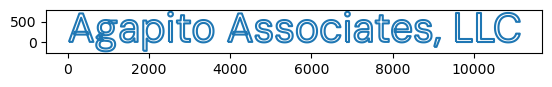

In [260]:

# striped_pants = r"C:\Users\bauer\Pictures\AgapitoPants3Stripe.svg"
# pants = r"C:\Users\bauer\Pictures\AAI Logo_Pants Only.svg"
# contours = svg_to_contours(striped_pants)
# # Fix raw orientation
# c2 = []
# for x in contours:
#     x2 = x.copy()
#     x2[:,0] = x[:,1]  *-1
#     x2[:,1] = x[:,0] #* -1
#     c2.append(x2)

# # Bring to 0-1
# a = np.concatenate(c2)
# minx, maxx, miny, maxy = a[:,0].min(), a[:,0].max(), a[:,1].min(), a[:,1].max()
# dx = maxx - minx
# dy = maxy - miny

# # Bring x & y to 0
# z = np.array([-1*minx, -1*miny])
# c2 = [x + z for x in c2]
# c2 = [x / dx for x in c2] # dx is the larger axis

def simplify(self, tolerance):
    gdf = gpd.GeoDataFrame({'geometry':[LineString(x) for x in contours]})
    print(gdf.shape)
    gdf = gdf.simplify(tolerance)
    print(gdf.shape)
    gdf.plot()
    s2 = gdf.geometry.apply(lambda x: np.array(x.coords[:])).tolist()
    return s2

In [42]:
## From pulling surfac informaton
xmin, ymin, xmax, ymax = wells.total_bounds
d = 500
bbox = box(xmin-d, ymin-d, xmax+d, ymax+d)
utmcrs = 'EPSG:26915'
bboxgdf = gpd.GeoDataFrame({'geometry':[bbox]}, crs=crs) #.to_crs(utmcrs)

In [46]:
import rasterio
from rasterio.mask import mask
import numpy as np
from shapely.geometry import Polygon

# Define your input/output paths and the conversion factor
input_path = r"C:\scipts\1138-01\python\SiteWideModel\DEM_merged_1m_zft_26872.tif" #"DEM_merged_1m.tif"
output_path = "DEM_merged_1m_cropped_zft_b.tif"

input_path = r"C:\scipts\1138-01\DEM\m_3009345_se_15_030_20230730_267892.tif"#r"C:\scipts\1138-01\DEM\m_3009345_se_15_030_20230730.tif"
output_path = "Cropped_aerial_b.tif"

conversion_factor = 1 #3.28084  # e.g., meters to feet

# 1. Define your Shapely geometry (Example Polygon)
# Ensure the geometry's CRS matches your GeoTIFF's CRS
geom = bboxgdf.geometry.values[0]

# 2. Open the input raster and crop it using the geometry
with rasterio.open(input_path) as src:
    # Crop the raster to the geometry
    cropped_image, out_transform = mask(src, shapes=[geom], crop=True)
    
    # 3. Multiply the Z-axis (all bands) by 3.28084
    # (Optional: If your raster has a NoData value, you may want to mask those pixels first)
    scaled_image = cropped_image * conversion_factor
    
    # 4. Set all values below 0 to a specific NoData value (e.g., -9999)
    #nodata_value = -9999.0
    #scaled_image[scaled_image < 0] = nodata_value
    
    # 4. Update the metadata to reflect the new dimensions, transform, and datatype
    out_meta = src.meta.copy()
    out_meta.update({
        "driver": "GTiff",
        "height": scaled_image.shape[1],
        "width": scaled_image.shape[2],
        "transform": out_transform,
        "dtype": scaled_image.dtype
    })
    
    # 5. Save the modified and cropped output GeoTIFF
    with rasterio.open(output_path, "w", **out_meta) as dest:
        dest.write(scaled_image)


C:\Users\bauer\.conda\envs\geo3d\Lib\site-packages\rasterio\mask.py:191: NodataShadowWarning: The dataset's nodata attribute is shadowing the alpha band. All masks will be determined by the nodata attribute
  out_image = dataset.read(


In [52]:
def getLabelPoints(label,xyz0=(0,0,0),spacing=0.3,
                   scaling=20,
                   letterscaleX=0.5, 
                   theta=0, 
                   azimuth=0, inclination=0):
    '''
    Makes a label along the x axis in the xy plane.
    
    -Adjust theta to rotate around the x axis (-90 is "standing up" text)
    -Adjust azimuth to rotate text around the z-axis
    '''
    letters = {
    'A': [(0, 0), (0.5, 1), (1, 0), (0.75,0.5),(0.25, 0.5)],#
    'B': [(0, 0), (0, 1), (0.9, 1), (1, 0.9), (1, 0.6), (0.9, 0.5), (0,0.5), (0.9, 0.5),
         (1,0.4),(1,0.1),(0.9,0),(0,0)],
    'C': [(0.7, 0), (0.3, 0), (0, 0.3), (0, 0.7), (0.3, 1), (0.7, 1)],
    'D': [(0, 0), (0, 1), (0.9, 1), (1, 0.9), (1, 0.1), (0.9, 0),(0,0)],#
    'E': [(1,0),(0, 0),(0,0.5),(0.9,0.5),(0,0.5), (0, 1), (1, 1)],
    'F': [(0, 0),(0,0.5),(0.9,0.5),(0,0.5), (0, 1), (1, 1)],
    
    'G': [(0.7, 0.5), (1, 0.5), (1, 0.1), (0.9, 0), (0.1, 0), (0, 0.1), (0, 0.9), (0.1, 1),(0.9,1),(1,0.9)],
    'H': [(0, 0), (0, 1), (0, 0.5), (1, 0.5), (1, 0), (1, 1)],
    'I': [(0, 0), (1, 0), (0.5, 0), (0.5, 1), (0, 1), (1, 1)],
    'J': [(0, 1), (1, 1), (0.5, 1), (0.5, 0.1), (0.4, 0),(0.1,0),(0,0.1),(0,0.2)],
    'K': [(0, 0), (0, 1), (0, 0.5), (1, 1), (0, 0.5), (1, 0)],
    'L': [(1,0),(0, 0), (0, 1)],
    'M': [(0, 0), (0, 1), (0.5, 0.5), (1, 1), (1, 0)],
    'N': [(0, 0), (0, 1), (1, 0), (1, 1)],
    'O': [(0.25, 0), (0, 0.25), (0, 0.75), (0.25, 1), (0.75, 1), (1, 0.75), (1, 0.25), (0.75, 0),(0.25,0)],
    
    'P': [(0, 0), (0, 1), (0.9, 1), (1,0.9),(1,0.6),(0.9, 0.5), (0, 0.5)],
    
    'Q': [(0.25, 0), (0, 0.25), (0, 0.75), (0.25, 1), (0.75, 1), (1, 0.75), (1, 0.25), (0.75, 0), (0.5, 0.5)],
    'R': [(0, 0), (0, 1), (0.6, 1), (0.6, 0.5), (0, 0.5), (0.6, 0)],
    'S': [(0.6, 1), (0, 1), (0, 0.5), (0.6, 0.5), (0.6, 0), (0, 0)],
    'T': [(0, 1), (1, 1), (0.5, 1), (0.5, 0)],
    'U': [(0, 1), (0, 0), (1, 0), (1, 1)],
    'V': [(0, 1), (0.5, 0), (1, 1)],
    'W': [(0, 1), (0.25, 0), (0.5, 1), (0.75, 0), (1, 1)],#
    'X': [(0, 0), (1, 1), (0.5, 0.5), (1, 0), (0, 1)],
    'Y': [(0, 1), (0.5, 0.5), (1, 1), (0.5, 0.5), (0.5, 0)],
    'Z': [(0, 1), (1, 1), (0, 0), (1, 0)],

    '0': [(0.25, 0), (0, 0.25), (0, 0.75), (0.25, 1), (0.75, 1), (1, 0.75), (1, 0.2), (0.75, 0), (0.25, 0)],
    '1': [(0.5, 0), (0.5, 1)],
    
    '2': [(0, 0.75), (0, 0.9), (0,0.9), (0.1,1), (0.9,1),(1, 0.9), (1, 0.75), (0.95,0.65),(0, 0),(0,0), (1, 0)],#
    
    '3': [(0, 0.8), (0, 0.9), (0,0.9), (0.1,1), (0.9,1),(1, 0.9),
          (1,0.6),(0.9,0.5),(0.5,0.5),(0.9,0.5),(1,0.4),(1,0.1),(0.9,0),
         (0.1,0),(0,0.1),(0,0.2)],  #
    
    '4': [(0, 1), (0, 0.5), (1, 0.5), (1, 1), (1, 0)],#
    
    '5': [(0, 0), (0.9, 0), (1,0.1), (1, 0.4), (0.9,0.5), (0, 0.5), (0, 1), (1, 1)],#
    '6': [(1,0.9),(0.9,1),(0.1,1),(0,0.9),(0,0.1),(0.1,0),(0.9,0),(1,0.1),(1,0.4),(0.9,0.5),(0.1,0.5),(0, 0.4)],
    '7': [(0, 0), (1, 1), (0, 1)],
    '8': [(0, 0), (0,0.5), (1,0.5), (0,0.5),(0, 1), (1, 1), (1, 0), (0, 0), (1, 0), (1, 1)],
    '9': [(0, 0), (1,0), (1, 1), (0, 1), (0, 0.5), (1, 0.5)],
    
    '-':[(0.25,0.5),(0.75,0.5)],
    ' ':[],
    ',':[(0,0),(0.09,0),(0.07,-0.02),(0.1,0),(0.1,0.1),(0,0.1),(0,0)],
    '.':[(0,0),(0.1,0),(0.1,0.1),(0,0.1),(0,0)],
    "'":[(0,1),(0.1,1),(0.1,0.8),(0,0.8),(0,1)],
    "_":[(0,0),(1,0)],
    "!":[(0,0),(0.1,0),(0.1,0.1),(0,0.1),(0,0),(0,0.2),(0.05,0.2),(0.1,1),(0,1),(0,0.2)],
    "~":[(0.0, 0.5), (0.08, 0.62), (0.17, 0.71), (0.25, 0.75), (0.33, 0.73), (0.42, 0.65), (0.5, 0.54), (0.58, 0.41), (0.67, 0.31),
         (0.75, 0.26), (0.83, 0.26), (0.92, 0.32), (1.0, 0.43)]

    }
    xl,yl = 0,0
    x0,y0,z0 = xyz0 #origin
    
    azimuth_rad = np.radians(azimuth)
    # Define rotation matrix for rotating around the Z-axis by azimuth angle
    azi_rotation_matrix = np.array([
        [np.cos(azimuth_rad), -np.sin(azimuth_rad), 0],
        [np.sin(azimuth_rad), np.cos(azimuth_rad), 0],
        [0, 0, 1]])

    theta_rad = np.radians(theta)
    theta_rotation_matrix = np.array([
        [1, 0, 0],
        [0, np.cos(theta_rad), -np.sin(theta_rad)],
        [0, np.sin(theta_rad), np.cos(theta_rad)]
    ])
    
    inclination_rad = np.radians(inclination)
    # Define rotation matrix for rotating around the X-axis by inclination angle
    inc_rotation_matrix = np.array([
        [np.cos(inclination_rad), 0, np.sin(inclination_rad)],
        [0, 1, 0],
        [-np.sin(inclination_rad), 0, np.cos(inclination_rad)]
    ])


    labelPoints = []

    for il,letter in enumerate(label):
        coords = letters[letter.upper()]
        if len(coords) == 0:
            xl += (1+spacing)*scaling*letterscaleX
            continue
        x, y =zip(*coords)
        if letter.isupper():
            capscale = 1
        else:
            capscale = 0.75
        x = [px*letterscaleX for px in x]
        x = [px*scaling + xl for px in x]
        y = [py*scaling*capscale + yl for py in y]

        xl += (1+spacing)*scaling*letterscaleX #use yl for verticle text
        z = [0]*len(x)
        letterPoints = [p for p in zip(x,y,z)]
        
        # Run Theta first
        if theta != 0:
            letterPoints = np.dot(letterPoints, theta_rotation_matrix)
            
        if inclination != 0:
            letterPoints = np.dot(letterPoints, inc_rotation_matrix) 
            
        if azimuth != 0:
            letterPoints = np.dot(letterPoints, azi_rotation_matrix)


        letterPoints = [(x + x0, y + y0, z + z0) for (x,y,z) in letterPoints]
        labelPoints.append(letterPoints)

    return labelPoints

def make_circ(xyz=(0,0,0),r=5):
    x0,y0,z0 = xyz
    num_segments = 16

    # Generate angles for each segment
    angles = np.linspace(0, 2*np.pi, num_segments, endpoint=False)
    
    # Compute (x, y) coordinates for each angle
    x_coordinates = r * np.cos(angles)
    y_coordinates = r * np.sin(angles)
    
    # Combine x and y coordinates
    coordinates = np.column_stack((x_coordinates, y_coordinates))
    coords =  np.round(coordinates,5) + np.array([x0,y0])
    coords = [(p[0],p[1],z0) for p in coords]
    coords = coords + coords[0:1]
    return coords

def make_cross(xyz=(0,0,0),r=10):
    x0,y0,z0 = xyz
    return [[(x0 + r,y0,z0),(x0 - r,y0,z0)],[(x0, y0 + r,z0),(x0,y0 - r,z0)]]

def make_well_mark(xyz=(0,0,0),r=10):
    cross = make_cross(xyz=xyz,r=r)
    cross.append(make_circ(xyz=xyz,r=r/2))
    return cross 

In [59]:
import fitz  # PyMuPDF
from PIL import Image
import io


def compress_pdf(
    input_pdf,
    output_pdf,
    dpi=100,
    grayscale=True,
    bw=False,
    jpeg_quality=50,
):
    """
    Compress a PDF by rendering each page as an image.

    Parameters
    ----------
    input_pdf : str
        Input PDF filename.
    output_pdf : str
        Output PDF filename.
    dpi : int, default=100
        Rendering resolution. Lower values produce smaller files.
    grayscale : bool, default=True
        Convert pages to grayscale.
    bw : bool, default=False
        Convert to 1-bit black & white (smallest files for text).
    jpeg_quality : int, default=50
        JPEG quality (1-100).
    """

    doc = fitz.open(input_pdf)

    images = []

    zoom = dpi / 72.0
    matrix = fitz.Matrix(zoom, zoom)

    for page in doc:
        pix = page.get_pixmap(matrix=matrix, alpha=False)

        img = Image.frombytes(
            "RGB",
            (pix.width, pix.height),
            pix.samples,
        )

        if bw:
            # Adaptive threshold to pure black & white
            img = img.convert("L").point(
                lambda x: 255 if x > 180 else 0,
                mode="1",
            )
        elif grayscale:
            img = img.convert("L")

        images.append(img)

    doc.close()

    if not images:
        raise ValueError("PDF contains no pages.")

    # images[0].save(
    #     output_pdf,
    #     save_all=True,
    #     append_images=images[1:],
    #     optimize=True,
    #     quality=jpeg_quality,
    #     resolution=dpi,
    # )
    if bw:
        images[0].save(
            output_pdf,
            save_all=True,
            append_images=images[1:],
            optimize=True,
            resolution=dpi,
        )
    else:
        images[0].save(
            output_pdf,
            save_all=True,
            append_images=images[1:],
            optimize=True,
            quality=jpeg_quality,
            resolution=dpi,
        )

compress_pdf(
    r"C:\Users\bauer\Downloads\836Torrey.pdf",
    r"C:\Users\bauer\Downloads\836Torrey_small.pdf",
    dpi=150,
    bw=True,
)